# Implementing `losneomrade` from Scratch

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import rasterio
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.spatial import distance_matrix
import requests
import warnings
from urllib.request import urlopen
from rasterio import MemoryFile
from rasterio.features import rasterize, shapes
from shapely.geometry.base import BaseGeometry
from typing import Union, List
from scipy.ndimage import binary_dilation
from tqdm.notebook import tqdm
from PIL import Image
import io
import os
from matplotlib.colors import LightSource
import tempfile
from shapely.geometry import LineString, Point

## Part 1: Terrain Criteria Analysis

Following the report, we'll first implement the **Terrain Criteria** methodology. This involves calculating slope angles from a set of source points across a Digital Elevation Model (DEM) to identify areas prone to instability.

Our first step is to get the necessary elevation data. We'll implement a function to download DEM data from Norway's public data service, `hoydedata.no`.

In [2]:
# Define a constant for the default layer to use from Høydedata
HOYDEDATA_LAYER = "NHM_DTM_25833"

def get_hoydedata(bounds: tuple, layer: str = HOYDEDATA_LAYER, res: int = 5, nodata: int = -9999, max_retries=5) -> dict:
    """
    Downloads a Digital Elevation Model (DEM) from Norway's public data service (www.høydedata.no).

    Args:
        bounds (tuple): A tuple defining the bounding box for the DEM in the format (xmin, xmax, ymin, ymax).
        layer (str, optional): The specific Høydedata API layer to use. Defaults to "NHM_DTM_25833".
        res (int, optional): The desired resolution of the output DEM in meters. The data will be resampled if the
                             resolution is different from the source layer. Defaults to 5.
        nodata (int, optional): The value to represent no data in the raster. Defaults to -9999.
        max_retries (int, optional): The maximum number of times to retry the download in case of an error. Defaults to 5.

    Returns:
        dict: A dictionary containing the DEM data and metadata:
              - "profile" (dict): The rasterio profile for the DEM, including transform, CRS, etc.
              - "full_array" (np.ndarray): A 2D NumPy array of the elevation data.
    """
    # Unpack the bounding box into individual coordinate values
    xmin, xmax, ymin, ymax = bounds
    
    # Calculate the width of the output raster in pixels based on the desired resolution
    width = int((xmax - xmin) / res)
    
    # Calculate the height of the output raster in pixels based on the desired resolution
    height = int((ymax - ymin) / res)

    # Construct the URL for the API request to Høydedata
    # This URL specifies the bounding box, output size, format, and other parameters
    request_url = (
        f"https://hoydedata.no/arcgis/rest/services/{layer}/ImageServer/exportImage?"
        f"bbox={xmin},{ymin},{xmax},{ymax}&size={width},{height}&bboxSR=&size=&imageSR=&time=&format=tiff&"
        f"pixelType=F32&noData={nodata}&noDataInterpretation=esriNoDataMatchAny"
        f"&interpolation=+RSP_BilinearInterpolation&compression=&compressionQuality=&"
        f"bandIds=&mosaicRule=&renderingRule=&f=image"
    )

    # Initialize the attempt counter for retry logic
    attempts = 0
    
    # Set the initial wait time between retries
    wait_time = 1
    
    # Retry loop to handle temporary network or server errors
    while attempts < max_retries:
        try:
            # Attempt to open the URL and read the response as bytes (TIFF file)
            tif_bytes = urlopen(request_url).read()
            
            # If successful, break out of the retry loop
            break
        except Exception as e:
            # Increment the attempt counter
            attempts += 1
            
            # Wait before retrying to avoid overwhelming the server
            time.sleep(wait_time)
    else:
        # If all retries are exhausted, raise an exception
        raise Exception("Error (Probably area requested is too big/small or høydedata is down)")

    # Open the TIFF data from memory using rasterio's MemoryFile
    with MemoryFile(tif_bytes) as memfile:
        # Open the dataset within the memory file
        with memfile.open() as dataset:
            # Extract the rasterio profile (metadata like CRS, transform, dimensions, etc.)
            dataset_profile = dataset.profile
            
            # Read the first (and only) band of the raster as a 2D NumPy array
            full_array = dataset.read(1)

    # Return a dictionary containing the profile and the elevation data array
    return {
        "profile": dataset_profile,
        "full_array": full_array
    }

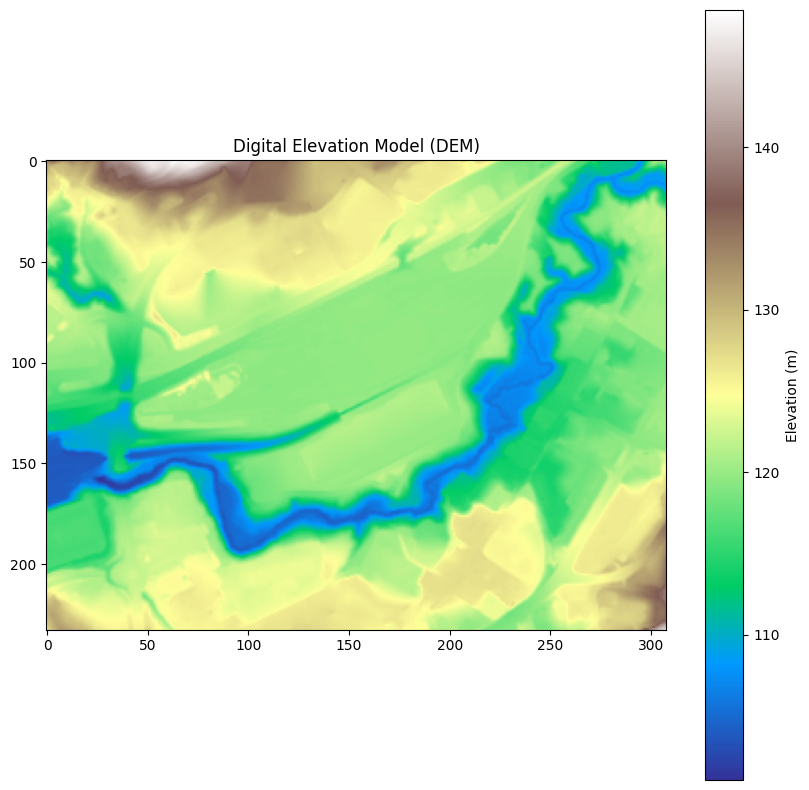

In [3]:
# Define the bounds for the area of interest
xmin, xmax, ymin, ymax = 268463.9, 270007.6, 6651396.2, 6652564.4
bounds = (xmin, xmax, ymin, ymax)

# Get the DEM data
dem_data = get_hoydedata(bounds)

# Plot the DEM
plt.figure(figsize=(10, 10))
plt.imshow(dem_data["full_array"], cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('Digital Elevation Model (DEM)')
plt.show()

### Understanding the Affine Transform

The **affine transform** is a mathematical mapping that converts pixel coordinates (row, col) in a raster to real-world geographic coordinates (x, y). It's stored as a 6-parameter transformation matrix.

#### The Affine Transform Equation

The transformation from pixel coordinates to geographic coordinates is given by:

$$
\begin{align}
x &= a \cdot col + b \cdot row + x_0 \\
y &= d \cdot col + e \cdot row + y_0
\end{align}
$$

Where:
- $(row, col)$ = pixel coordinates (starting from 0)
- $(x, y)$ = real-world geographic coordinates
- $a$ = pixel width (size of a pixel in the x-direction)
- $b$ = row rotation (typically 0 for north-up images)
- $x_0$ = x-coordinate of the upper-left corner
- $d$ = column rotation (typically 0 for north-up images)
- $e$ = pixel height (size of a pixel in the y-direction, typically negative)
- $y_0$ = y-coordinate of the upper-left corner

#### For a Standard North-Up Raster

In most cases (like our DEM), the raster is aligned with north being up, so the rotation terms are zero:

$$
\begin{align}
x &= a \cdot col + x_0 \\
y &= e \cdot row + y_0
\end{align}
$$

Where:
- $a > 0$ (pixel width, e.g., 5 meters)
- $e < 0$ (pixel height is negative because row increases downward while y increases upward)

#### Example

If our DEM has:
- Resolution: 5 meters
- Upper-left corner at: $(x_0, y_0) = (268463.9, 6652564.4)$

Then the affine parameters are:
- $a = 5$ (5 meters per pixel in x-direction)
- $b = 0$ (no rotation)
- $x_0 = 268463.9$ (starting x-coordinate)
- $d = 0$ (no rotation)
- $e = -5$ (5 meters per pixel in y-direction, negative because y decreases as row increases)
- $y_0 = 6652564.4$ (starting y-coordinate)

So to find the geographic coordinates of pixel at row=10, col=20:

$$
\begin{align}
x &= 5 \cdot 20 + 268463.9 = 268563.9 \\
y &= -5 \cdot 10 + 6652564.4 = 6652514.4
\end{align}
$$

#### The Inverse Transform

To go from geographic coordinates $(x, y)$ back to pixel coordinates $(row, col)$, we use the inverse:

$$
\begin{align}
col &= \frac{x - x_0}{a} \\
row &= \frac{y - y_0}{e}
\end{align}
$$

This is what `rasterio.transform.rowcol(transform, x, y)` does when we sample the DEM at specific points!

In [4]:
# Let's examine the affine transform from our DEM
transform = dem_data["profile"]["transform"]
print("Affine Transform:")
print(transform)
print("\nAffine parameters:")
print(f"a (pixel width): {transform.a}")
print(f"b (row rotation): {transform.b}")
print(f"x_0 (upper-left x): {transform.c}")
print(f"d (col rotation): {transform.d}")
print(f"e (pixel height): {transform.e}")
print(f"y_0 (upper-left y): {transform.f}")

# Example: Convert pixel (row=10, col=20) to geographic coordinates
row, col = 10, 20
x, y = rasterio.transform.xy(transform, row, col)
print(f"\nPixel ({row}, {col}) -> Geographic coordinates ({x:.2f}, {y:.2f})")

# Example: Convert geographic coordinates back to pixel
x_test, y_test = 268563.9, 6652514.4
row_back, col_back = rasterio.transform.rowcol(transform, x_test, y_test)
print(f"Geographic ({x_test}, {y_test}) -> Pixel ({row_back}, {col_back})")

# Verify the math manually
print("\nManual calculation:")
print(f"x = {transform.a} * {col} + {transform.c} = {transform.a * col + transform.c:.2f}")
print(f"y = {transform.e} * {row} + {transform.f} = {transform.e * row + transform.f:.2f}")

Affine Transform:
| 5.01, 0.00, 268463.63|
| 0.00,-5.01, 6652564.40|
| 0.00, 0.00, 1.00|

Affine parameters:
a (pixel width): 5.0137339055802
b (row rotation): 0.0
x_0 (upper-left x): 268463.63497854065
d (col rotation): 0.0
e (pixel height): -5.013733905580199
y_0 (upper-left y): 6652564.4

Pixel (10, 20) -> Geographic coordinates (268566.42, 6652511.76)
Geographic (268563.9, 6652514.4) -> Pixel (9, 19)

Manual calculation:
x = 5.0137339055802 * 20 + 268463.63497854065 = 268563.91
y = -5.013733905580199 * 10 + 6652564.4 = 6652514.26


In [5]:
print("All DEM data:", dem_data)
print("DEM profile:", dem_data['profile'])
print("DEM array shape and data:", dem_data['full_array'].shape, dem_data['full_array'])

All DEM data: {'profile': {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -9999.0, 'width': 308, 'height': 233, 'count': 1, 'crs': CRS.from_wkt('PROJCS["ETRS89 / UTM zone 33N",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","25833"]]'), 'transform': Affine(5.0137339055802, 0.0, 268463.63497854065,
       0.0, -5.013733905580199, 6652564.4), 'blockxsize': 128, 'blockysize': 128, 'tiled': True, 'interleave': 'band'}, 'full_array': array([[133.01712 , 134.32141 , 135.29283 

### Step 2: Define Source Points and Calculate Slopes

Now that we have the DEM, we need to implement the core logic of the terrain criteria analysis. This involves three main parts:

1.  **Get DEM Coordinates**: We need a function to convert the DEM from a 2D grid of elevation values into a list of 3D coordinates (x, y, z) for every pixel.
2.  **Set Source Point Elevation**: Our source points are initially 2D (x, y). We need to find their elevation (z-value) by sampling the DEM.
3.  **Compute Slope**: This is the main calculation. For every pixel in the DEM, we'll calculate the slope between it and all of the source points, keeping the maximum slope value. The slope is calculated as the ratio of vertical height difference to horizontal distance.

In [6]:
def dem_coordinates(dem_array: np.ndarray, dem_transform: rasterio.transform.Affine) -> np.ndarray:
    """
    Converts a DEM array into a set of 3D coordinates (x, y, z).

    Args:
        dem_array (np.ndarray): The 2D NumPy array of the DEM.
        dem_transform (rasterio.transform.Affine): The affine transformation of the DEM.

    Returns:
        np.ndarray: A NumPy array of shape (n_pixels, 3) with the x, y, and z coordinates.
    """
    # Get the height (number of rows) and width (number of columns) of the DEM
    height, width = dem_array.shape
    
    # Create a 2D grid of column and row indices
    # cols will contain column numbers, rows will contain row numbers
    cols, rows = np.meshgrid(np.arange(width), np.arange(height))
    
    # Convert the row/column indices to real-world x, y coordinates using the affine transform
    xs, ys = rasterio.transform.xy(dem_transform, rows, cols)
    
    # Combine x, y coordinates with elevation (z) values into a single 3D coordinate array
    # flatten() converts the 2D arrays into 1D arrays
    # np.c_ concatenates arrays column-wise
    coords = np.c_[np.array(xs).flatten(), np.array(ys).flatten(), dem_array.flatten()]
    
    # Return the array of 3D coordinates
    return coords

In [7]:
# Test the dem_coordinates function
print("INPUT to dem_coordinates:")
print(f"  DEM shape: {dem_data['full_array'].shape}")
print(f"  DEM sample values (first 5x5):\n{dem_data['full_array'][:5, :5]}")
print(f"  Transform: {dem_data['profile']['transform']}")

# Call the function
dem_coords = dem_coordinates(dem_data["full_array"], dem_data["profile"]["transform"])

print("\nOUTPUT from dem_coordinates:")
print(f"  Output shape: {dem_coords.shape}")
print(f"  First 5 coordinates (x, y, z):\n{dem_coords[:5]}")
print(f"  Last 5 coordinates (x, y, z):\n{dem_coords[-5:]}")

INPUT to dem_coordinates:
  DEM shape: (233, 308)
  DEM sample values (first 5x5):
[[133.01712 134.32141 135.29283 135.5649  135.1736 ]
 [132.37906 132.87675 133.20807 133.09299 132.35934]
 [131.06512 131.21689 130.80191 130.40593 129.95311]
 [130.65724 130.20074 129.41267 129.44392 129.3602 ]
 [131.01842 130.11473 128.43254 128.49687 128.82674]]
  Transform: | 5.01, 0.00, 268463.63|
| 0.00,-5.01, 6652564.40|
| 0.00, 0.00, 1.00|

OUTPUT from dem_coordinates:
  Output shape: (71764, 3)
  First 5 coordinates (x, y, z):
[[2.68466142e+05 6.65256189e+06 1.33017120e+02]
 [2.68471156e+05 6.65256189e+06 1.34321411e+02]
 [2.68476169e+05 6.65256189e+06 1.35292831e+02]
 [2.68481183e+05 6.65256189e+06 1.35564896e+02]
 [2.68486197e+05 6.65256189e+06 1.35173599e+02]]
  Last 5 coordinates (x, y, z):
[[2.69985303e+05 6.65139871e+06 1.42319458e+02]
 [2.69990317e+05 6.65139871e+06 1.43338562e+02]
 [2.69995331e+05 6.65139871e+06 1.44094955e+02]
 [2.70000344e+05 6.65139871e+06 1.44719543e+02]
 [2.70005358

In [8]:
def set_z_from_raster(points_xy: np.ndarray, dem_data: dict) -> np.ndarray:
    """
    Assigns elevation values (z) to a set of 2D points (x, y) by sampling a DEM.

    Args:
        points_xy (np.ndarray): A NumPy array of shape (n_points, 2) with the x, y coordinates.
        dem_data (dict): The dictionary returned by `get_hoydedata`, containing the DEM and its profile.

    Returns:
        np.ndarray: A NumPy array of shape (n_points, 3) with the x, y, and z coordinates.
    """
    # Extract the DEM elevation array from the data dictionary
    dem_array = dem_data["full_array"]
    
    # Extract the affine transform from the profile
    transform = dem_data["profile"]["transform"]
    
    # Extract the nodata value from the profile
    nodata = dem_data["profile"]["nodata"]
    
    # Convert each (x, y) coordinate to pixel row and column indices
    # rasterio.transform.rowcol returns (row, col) for each (x, y) point
    indices = np.array([rasterio.transform.rowcol(transform, x, y) for x, y in points_xy])
    
    # Sample the DEM array at the calculated indices to get elevation values
    # For each (row, col) pair, we get the corresponding elevation
    z_values = np.array([dem_array[row, col] for row, col in indices])
    
    # Create a boolean mask to filter out points that fall on nodata pixels
    valid_mask = z_values != nodata
    
    # Combine the x, y coordinates with the z values, then filter by the valid mask
    # This removes any points that had nodata elevations
    return np.c_[points_xy, z_values][valid_mask]

In [9]:
# Define source points (from the original notebook)
source_points_xy = np.array([
    (268883.5400622159, 6651785.961672257), (268917.3041989159, 6651614.686395486),
    (268952.34858209593, 6651598.08903631), (269098.9750438174, 6651692.086224091),
    (269136.0121169521, 6651688.541504248), (269187.3338556726, 6651662.554160272),
    (269266.9063958938, 6651685.158933432), (269327.31869611563, 6651689.869289508),
    (269385.2269397425, 6651692.168949791), (269430.1044651593, 6651718.1729600765),
    (269417.70676140685, 6651750.211168494), (269417.9726969357, 6651774.200699851),
    (269471.1996794914, 6651798.455341154), (269514.28554422176, 6651813.7414565245),
    (269552.6144975672, 6651849.758094928), (269566.83348302596, 6651865.730493411),
    (269573.36843977927, 6651894.129818862)
])

print("INPUT to set_z_from_raster:")
print(f"  Source points shape: {source_points_xy.shape}")
print(f"  First 3 source points (x, y):\n{source_points_xy[:3]}")
print(f"  DEM nodata value: {dem_data['profile']['nodata']}")

# Call the function
source_points_3d = set_z_from_raster(source_points_xy, dem_data)

print("\nOUTPUT from set_z_from_raster:")
print(f"  Output shape: {source_points_3d.shape}")
print(f"  All source points with elevations (x, y, z):\n{source_points_3d}")

INPUT to set_z_from_raster:
  Source points shape: (17, 2)
  First 3 source points (x, y):
[[ 268883.54006222 6651785.96167226]
 [ 268917.30419892 6651614.68639549]
 [ 268952.3485821  6651598.08903631]]
  DEM nodata value: -9999.0

OUTPUT from set_z_from_raster:
  Output shape: (17, 3)
  All source points with elevations (x, y, z):
[[2.68883540e+05 6.65178596e+06 1.04436211e+02]
 [2.68917304e+05 6.65161469e+06 1.06245758e+02]
 [2.68952349e+05 6.65159809e+06 1.04109497e+02]
 [2.69098975e+05 6.65169209e+06 1.05677582e+02]
 [2.69136012e+05 6.65168854e+06 1.04369164e+02]
 [2.69187334e+05 6.65166255e+06 1.04610168e+02]
 [2.69266906e+05 6.65168516e+06 1.05498367e+02]
 [2.69327319e+05 6.65168987e+06 1.04789749e+02]
 [2.69385227e+05 6.65169217e+06 1.05853279e+02]
 [2.69430104e+05 6.65171817e+06 1.05292625e+02]
 [2.69417707e+05 6.65175021e+06 1.05890556e+02]
 [2.69417973e+05 6.65177420e+06 1.06160133e+02]
 [2.69471200e+05 6.65179846e+06 1.05768494e+02]
 [2.69514286e+05 6.65181374e+06 1.06154274

In [10]:
def compute_slope(coords: np.ndarray, points: np.ndarray, h_min: float = 5, nodata: int = -9999) -> np.ndarray:
    """
    Computes the maximum slope from each DEM coordinate to a set of source points.

    Args:
        coords (np.ndarray): The 3D coordinates of the DEM pixels.
        points (np.ndarray): The 3D coordinates of the source points.
        h_min (float, optional): The minimum height difference to consider for slope calculation. Defaults to 5.
        nodata (int, optional): The value to use for no data. Defaults to -9999.

    Returns:
        np.ndarray: An array of the maximum slope values for each DEM coordinate.
    """
    # Suppress warnings that might occur during division operations
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Extract the x, y coordinates (first two columns) from the DEM coordinates
        xy_1 = coords[:, :2]
        
        # Extract the x, y coordinates (first two columns) from the source points
        xy_2 = points[:, :2]
        
        # Extract the z (elevation) values from the DEM coordinates
        z1 = coords[:, -1]
        
        # Extract the z (elevation) values from the source points
        z2 = points[:, -1]
        
        # Compute the distance matrix: horizontal distance between each DEM pixel and each source point
        # Result shape: (n_dem_pixels, n_source_points)
        distance_mtx = distance_matrix(xy_1, xy_2)
        
        # Compute the height difference matrix: vertical difference between each DEM pixel and each source point
        # z1[:, np.newaxis] converts z1 from shape (n,) to (n, 1) for broadcasting
        # Result shape: (n_dem_pixels, n_source_points)
        height_mtx = z1[:, np.newaxis] - z2
        
        # Calculate the slope ratio: height difference divided by horizontal distance
        # This gives the tangent of the slope angle (rise over run)
        hl_ratio = height_mtx / distance_mtx
        
        # Set slopes to nodata where the height difference is less than the minimum threshold
        # This prevents calculating slopes for very small height differences
        hl_ratio[height_mtx < h_min] = nodata
        
        # For each DEM pixel, find the maximum slope across all source points
        # axis=1 means we find the maximum along the source points dimension
        max_slope = np.max(hl_ratio, axis=1)

        # Return the array of maximum slopes
        return max_slope

In [11]:
print("INPUT to compute_slope:")
print(f"  DEM coordinates shape: {dem_coords.shape}")
print(f"  Source points shape: {source_points_3d.shape}")
print(f"  h_min: 5")
print(f"  Sample DEM coords (first 3):\n{dem_coords[:3]}")
print(f"  Sample source points (first 3):\n{source_points_3d[:3]}")

# Call the function
slope_map = compute_slope(dem_coords, source_points_3d, h_min=5)

print("\nOUTPUT from compute_slope:")
print(f"  Output shape: {slope_map.shape}")
print(f"  Min slope: {slope_map.min():.4f}")
print(f"  Max slope: {slope_map.max():.4f}")
print(f"  Mean slope: {slope_map.mean():.4f}")
print(f"  First 10 slope values: {slope_map[:10]}")

INPUT to compute_slope:
  DEM coordinates shape: (71764, 3)
  Source points shape: (17, 3)
  h_min: 5
  Sample DEM coords (first 3):
[[2.68466142e+05 6.65256189e+06 1.33017120e+02]
 [2.68471156e+05 6.65256189e+06 1.34321411e+02]
 [2.68476169e+05 6.65256189e+06 1.35292831e+02]]
  Sample source points (first 3):
[[2.68883540e+05 6.65178596e+06 1.04436211e+02]
 [2.68917304e+05 6.65161469e+06 1.06245758e+02]
 [2.68952349e+05 6.65159809e+06 1.04109497e+02]]

OUTPUT from compute_slope:
  Output shape: (71764,)
  Min slope: -9999.0000
  Max slope: 0.6833
  Mean slope: -761.3876
  First 10 slope values: [0.03243873 0.03401033 0.03520967 0.03561437 0.03525933 0.03450633
 0.03351902 0.03273289 0.0323098  0.0325779 ]


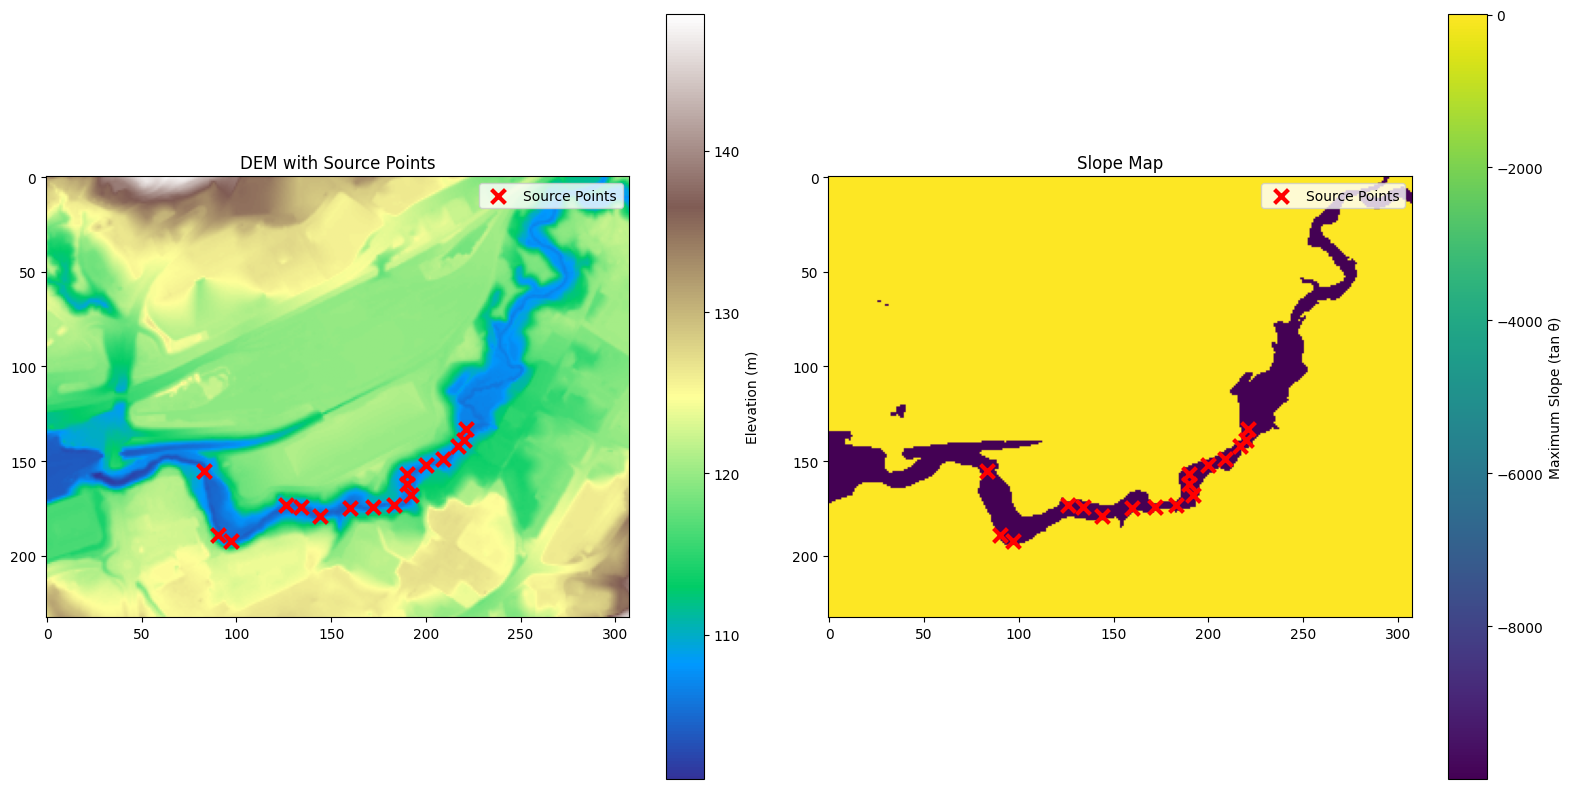

Final slope map shape: (233, 308)


In [12]:
# Reshape the slope map to match the DEM dimensions and visualize
slope_map_2d = slope_map.reshape(dem_data["full_array"].shape)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: DEM with source points
ax1 = axes[0]
dem_plot = ax1.imshow(dem_data["full_array"], cmap='terrain')
plt.colorbar(dem_plot, ax=ax1, label='Elevation (m)')

# Overlay source points (convert to pixel coordinates)
transform = dem_data["profile"]["transform"]
source_rows = []
source_cols = []
for x, y in source_points_xy:
    row, col = rasterio.transform.rowcol(transform, x, y)
    source_rows.append(row)
    source_cols.append(col)

ax1.scatter(source_cols, source_rows, c='red', s=100, marker='x', linewidths=3, label='Source Points')
ax1.set_title('DEM with Source Points')
ax1.legend()

# Plot 2: Slope map with source points
ax2 = axes[1]
slope_plot = ax2.imshow(slope_map_2d, cmap='viridis', vmax=0.3)
plt.colorbar(slope_plot, ax=ax2, label='Maximum Slope (tan θ)')
ax2.scatter(source_cols, source_rows, c='red', s=100, marker='x', linewidths=3, label='Source Points')
ax2.set_title('Slope Map')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final slope map shape: {slope_map_2d.shape}")

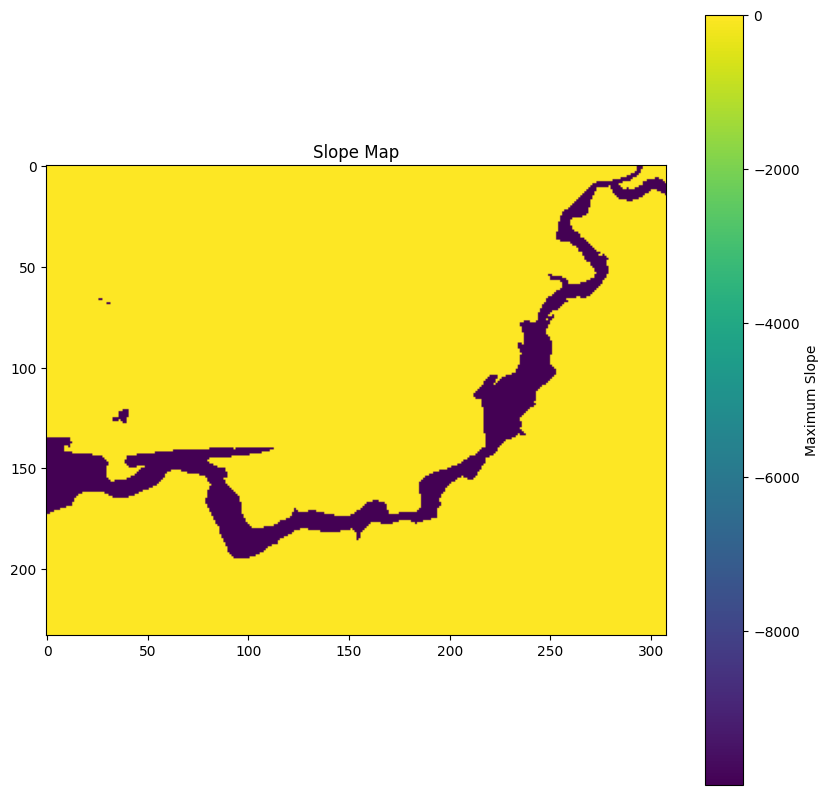

In [13]:
# Define source points (from the original notebook)
source_points_xy = np.array([
    (268883.5400622159, 6651785.961672257), (268917.3041989159, 6651614.686395486),
    (268952.34858209593, 6651598.08903631), (269098.9750438174, 6651692.086224091),
    (269136.0121169521, 6651688.541504248), (269187.3338556726, 6651662.554160272),
    (269266.9063958938, 6651685.158933432), (269327.31869611563, 6651689.869289508),
    (269385.2269397425, 6651692.168949791), (269430.1044651593, 6651718.1729600765),
    (269417.70676140685, 6651750.211168494), (269417.9726969357, 6651774.200699851),
    (269471.1996794914, 6651798.455341154), (269514.28554422176, 6651813.7414565245),
    (269552.6144975672, 6651849.758094928), (269566.83348302596, 6651865.730493411),
    (269573.36843977927, 6651894.129818862)
])

# Get the 3D coordinates for the DEM
dem_coords = dem_coordinates(dem_data["full_array"], dem_data["profile"]["transform"])

# Get the 3D coordinates for the source points
source_points_3d = set_z_from_raster(source_points_xy, dem_data)

# Compute the slopes
slope_map = compute_slope(dem_coords, source_points_3d)

# Reshape the slope map to match the DEM dimensions
slope_map_2d = slope_map.reshape(dem_data["full_array"].shape)

# Plot the slope map
plt.figure(figsize=(10, 10))
plt.imshow(slope_map_2d, cmap='viridis', vmax=0.3) # vmax is used to better visualize the slopes
plt.colorbar(label='Maximum Slope')
plt.title('Slope Map')
plt.show()

## Part 2: Understanding the Repository's Reclassification Function

Looking at the source code in `terrain_criteria.py`, the repository uses a `reclass()` function that categorizes continuous slope values into **6 discrete hazard classes** using these thresholds:

```python
classes = [0.05, 0.067, 0.2, 0.33, 1.7, 1000]
```

This creates:
- **Class 0**: slope < 0.05 (1:20) - Very gentle
- **Class 1**: 0.05 ≤ slope < 0.067 (1:15) - Gentle ← The 1V:1.5H criterion
- **Class 2**: 0.067 ≤ slope < 0.2 (1:5) - Moderate
- **Class 3**: 0.2 ≤ slope < 0.33 (1:3) - Steep
- **Class 4**: 0.33 ≤ slope < 1.7 (≈60°) - Very steep
- **Class 5**: slope ≥ 1.7 - Extreme

Let's use the repository's `reclass()` function on our computed slope map to see how it works.

In [16]:
import bisect

def reclass(matrix: np.ndarray) -> np.ndarray:
    """
    Reclassifies the terrain criteria results into discrete classes.
    This is the exact implementation from the losneomrade source code.
    
    Args:
        matrix: numpy array with continuous slope values (rise/run)
    
    Returns: 
        numpy array with reclassified terrain criteria results (0-5)
    """
    classes = [0.05, 0.067, 0.2, 0.33, 1.7, 1000]
    #         1:20   1:15   1:5   1:3  60°   extreme
    
    # Use bisect to find the class index for each value
    reclass_vectorized = np.vectorize(lambda x: bisect.bisect_left(classes, x))
    
    return reclass_vectorized(matrix)

# Apply reclassification to our slope map
slope_classes = reclass(slope_map_2d)

# Print class distribution
print("Slope Classification Results:")
print("=" * 60)
unique_classes, counts = np.unique(slope_classes[slope_map_2d >= 0], return_counts=True)
total_pixels = counts.sum()

class_labels = {
    0: "Very Gentle (< 1:20, < 0.05)",
    1: "Gentle (1:20 to 1:15, 0.05-0.067)",
    2: "Moderate (1:15 to 1:5, 0.067-0.2)",
    3: "Steep (1:5 to 1:3, 0.2-0.33)",
    4: "Very Steep (1:3 to 60°, 0.33-1.7)",
    5: "Extreme (> 60°, > 1.7)"
}

for cls, count in zip(unique_classes, counts):
    cls_int = int(cls)
    percentage = 100 * count / total_pixels
    print(f"Class {cls_int}: {class_labels.get(cls_int, 'Unknown'):40s} - {count:6,} pixels ({percentage:5.2f}%)")

print("=" * 60)

Slope Classification Results:
Class 0: Very Gentle (< 1:20, < 0.05)             - 39,612 pixels (59.75%)
Class 1: Gentle (1:20 to 1:15, 0.05-0.067)        -  7,771 pixels (11.72%)
Class 2: Moderate (1:15 to 1:5, 0.067-0.2)        - 16,420 pixels (24.77%)
Class 3: Steep (1:5 to 1:3, 0.2-0.33)             -  2,183 pixels ( 3.29%)
Class 4: Very Steep (1:3 to 60°, 0.33-1.7)        -    313 pixels ( 0.47%)


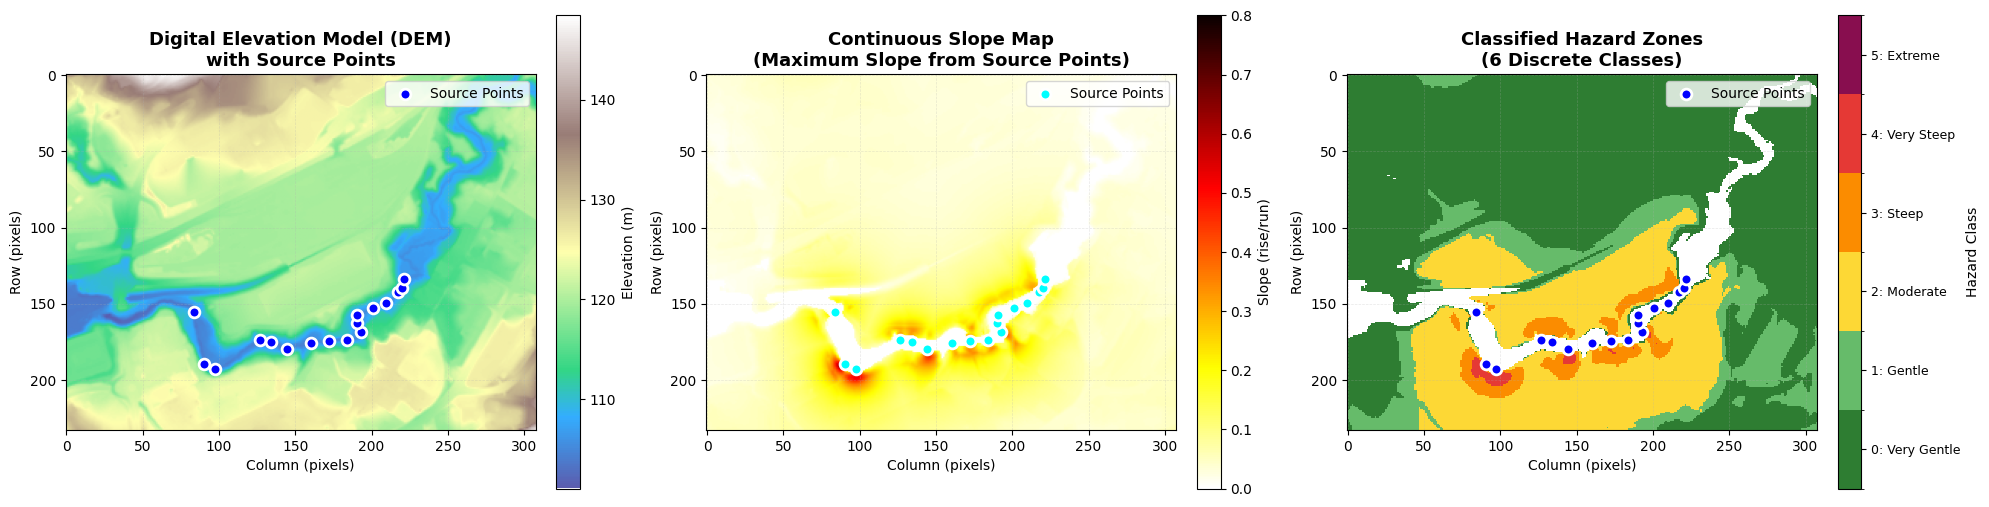

In [17]:
# Create a comprehensive visualization with the classified slopes
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define colors for each class (gradient from safe to dangerous)
from matplotlib.colors import ListedColormap, BoundaryNorm

class_colors = [
    '#2E7D32',  # Dark green - Very Gentle
    '#66BB6A',  # Light green - Gentle
    '#FDD835',  # Yellow - Moderate
    '#FB8C00',  # Orange - Steep
    '#E53935',  # Red - Very Steep
    '#880E4F'   # Dark red - Extreme
]
cmap_classes = ListedColormap(class_colors)
bounds = [0, 1, 2, 3, 4, 5, 6]
norm = BoundaryNorm(bounds, cmap_classes.N)

# Plot 1: DEM with source points
ax1 = axes[0]
dem_plot = ax1.imshow(dem_data["full_array"], cmap='terrain', alpha=0.8)
ax1.scatter(source_cols, source_rows, c='blue', s=60, marker='o', 
            edgecolors='white', linewidths=2, label='Source Points', zorder=5)
ax1.set_title('Digital Elevation Model (DEM)\nwith Source Points', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
cbar1 = plt.colorbar(dem_plot, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Elevation (m)', fontsize=10)

# Plot 2: Continuous slope map
ax2 = axes[1]
slope_continuous = ax2.imshow(slope_map_2d, cmap='hot_r', vmin=0, vmax=0.8)
ax2.scatter(source_cols, source_rows, c='cyan', s=60, marker='o', 
            edgecolors='white', linewidths=2, label='Source Points', zorder=5)
ax2.set_title('Continuous Slope Map\n(Maximum Slope from Source Points)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
cbar2 = plt.colorbar(slope_continuous, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Slope (rise/run)', fontsize=10)

# Plot 3: Classified slope map
ax3 = axes[2]
# Mask out negative/nodata values
slope_classes_masked = np.where(slope_map_2d < 0, np.nan, slope_classes)
class_plot = ax3.imshow(slope_classes_masked, cmap=cmap_classes, norm=norm, interpolation='nearest')
ax3.scatter(source_cols, source_rows, c='blue', s=60, marker='o', 
            edgecolors='white', linewidths=2, label='Source Points', zorder=5)
ax3.set_title('Classified Hazard Zones\n(6 Discrete Classes)', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Create custom colorbar for classes
cbar3 = plt.colorbar(class_plot, ax=ax3, fraction=0.046, pad=0.04, ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
cbar3.ax.set_yticklabels(['0: Very Gentle', '1: Gentle', '2: Moderate', 
                          '3: Steep', '4: Very Steep', '5: Extreme'], fontsize=9)
cbar3.set_label('Hazard Class', fontsize=10)

# Set common labels
for ax in axes:
    ax.set_xlabel('Column (pixels)', fontsize=10)
    ax.set_ylabel('Row (pixels)', fontsize=10)

plt.tight_layout()
plt.show()

### Understanding the Classification Results

From running the repository's `reclass()` function, we observe:

1. **Most terrain is very gentle**: ~60% falls into Class 0 (slope < 1:20)
2. **The 1V:1.5H threshold (0.067)** separates Classes 1 and 2
3. **Higher hazard classes are rare**: Only ~4% reaches "Steep" or "Very Steep"

The three-panel visualization demonstrates the repository's workflow:
- **Left**: Input DEM data with source points
- **Middle**: Continuous slope calculations (from `compute_slope()`)
- **Right**: Discretized output from `reclass()` function

This shows how the repository transforms raw elevation data → continuous slopes → categorical hazard zones.

## Part 3: Understanding Retrogression Analysis

So far we've explored the **terrain criteria** module which:
1. Downloads DEM data
2. Computes slopes from source points to all pixels
3. Classifies slopes into hazard categories

The repository has a second major component: **retrogression analysis** (`retrogression.py`). 

Looking at the source code, retrogression determines how avalanche/landslide zones propagate **backward** from release areas. Key parameters:
- `min_slope`: minimum slope criterion (default 1/15, same as our 1V:1.5H)
- `min_height`: minimum height difference to check (default 5m)
- `min_length`: minimum propagation distance before checking slope (default 75m)

The algorithm appears to:
1. Start from a release area (polygon/line/points)
2. Propagate backward iteratively
3. Stop when the slope criterion is no longer met

Let's explore what functions are used for this retrogression analysis.

In [18]:
# Let's examine the key functions used in retrogression analysis
# from the repository's retrogression.py module

print("Key Functions in retrogression.py:")
print("=" * 70)
print("\n1. run_retrogression() - Main wrapper function")
print("   - Gets DEM data")
print("   - Rasterizes release shape")
print("   - Calls landslide_retrogression()")
print("   - Returns polygonized results")

print("\n2. landslide_retrogression() - Core algorithm")
print("   - Takes: DEM, initial_release area, transform")
print("   - Parameters: min_slope (1/15), min_height (5m), min_length (75m)")
print("   - Iteratively propagates backward from release area")
print("   - Uses buffer/expand approach with slope checking")

print("\n3. Supporting functions we'd need to understand:")
print("   - create_buffer() - Expands the release area by 1 pixel")
print("   - compute_slope() - Already explored in Part 1")
print("   - polygonize_results() - Converts raster back to vector")

print("\n" + "=" * 70)
print("\nThe algorithm workflow:")
print("  1. Start with initial release area (rasterized)")
print("  2. Get coordinates and elevations of release pixels")
print("  3. Loop:")
print("     a. Buffer/expand the current release area by 1 pixel")
print("     b. For buffered pixels, compute slope back to release area")
print("     c. Check if slope > min_slope AND within distance criteria")
print("     d. Add qualifying pixels to release area")
print("     e. Stop when no new pixels qualify or max_length reached")
print("  4. Convert final raster back to polygon")
print("=" * 70)

Key Functions in retrogression.py:

1. run_retrogression() - Main wrapper function
   - Gets DEM data
   - Rasterizes release shape
   - Calls landslide_retrogression()
   - Returns polygonized results

2. landslide_retrogression() - Core algorithm
   - Takes: DEM, initial_release area, transform
   - Parameters: min_slope (1/15), min_height (5m), min_length (75m)
   - Iteratively propagates backward from release area
   - Uses buffer/expand approach with slope checking

3. Supporting functions we'd need to understand:
   - create_buffer() - Expands the release area by 1 pixel
   - compute_slope() - Already explored in Part 1
   - polygonize_results() - Converts raster back to vector


The algorithm workflow:
  1. Start with initial release area (rasterized)
  2. Get coordinates and elevations of release pixels
  3. Loop:
     a. Buffer/expand the current release area by 1 pixel
     b. For buffered pixels, compute slope back to release area
     c. Check if slope > min_slope AND withi

### Implementing the Buffer Function

A key function in retrogression is `create_buffer()` which expands a release area by one pixel. It uses **binary dilation** to grow the area, then subtracts the original to get only the new boundary pixels.

In [20]:
def create_buffer(image: np.ndarray, buffer_size: int = 1):
    """
    Create a buffer around an image by performing binary dilation.
    This is copied directly from the repository's retrogression.py
    
    Args:
        image (np.ndarray): Image as a numpy array (boolean or binary)
        buffer_size (int): Size of the buffer in pixels. Default is 1.
    
    Returns:
        np.ndarray: Buffer as a boolean numpy array (only the new boundary pixels)
    """
    # Dilate (expand) the image by the buffer size
    dilated_image = binary_dilation(image, iterations=buffer_size)
    
    # Subtract the original image to get only the new boundary pixels
    # Convert to int first to allow subtraction
    buffer = ((dilated_image.astype(int) - image.astype(int)) > 0).astype(bool)
    
    return buffer

# Test the buffer function with a simple example
print("Demonstrating create_buffer():")
print("=" * 60)

# Create a small test image with a single point
test_image = np.zeros((7, 7), dtype=bool)
test_image[3, 3] = True  # Center pixel

print("Original release area (1 pixel):")
print(test_image.astype(int))

# Create buffer of size 1
buffer_1 = create_buffer(test_image, buffer_size=1)
print("\nBuffer after 1 iteration (8 surrounding pixels):")
print(buffer_1.astype(int))

# Add buffer to release and create another buffer
release_expanded = test_image | buffer_1
buffer_2 = create_buffer(release_expanded, buffer_size=1)
print("\nAfter adding first buffer, next buffer (16 pixels):")
print(buffer_2.astype(int))
print(f"\nTotal pixels so far: {test_image.sum() + buffer_1.sum() + buffer_2.sum()}")
print("=" * 60)

Demonstrating create_buffer():
Original release area (1 pixel):
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]

Buffer after 1 iteration (8 surrounding pixels):
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]

After adding first buffer, next buffer (16 pixels):
[[0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 0 0 1 0]
 [0 0 1 0 1 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0]]

Total pixels so far: 13


### Simulating Simple Retrogression

Now let's simulate the retrogression algorithm on our actual DEM. We'll:
1. Start with a small initial release area around one source point
2. Iteratively expand it using the buffer function
3. Check slopes to determine which new pixels qualify
4. Visualize the progression

In [22]:
# Simplified retrogression simulation
# Using parameters from the repository
min_slope = 1/15  # Same as 1V:1.5H criterion
min_height = 5    # meters
min_length = 75   # meters (in pixels: 75/5 = 15 iterations before checking slope)
res = 5           # 5 meter resolution

min_iter = int(min_length // res)  # 15 iterations

print("Retrogression Parameters:")
print("=" * 60)
print(f"Minimum slope: {min_slope:.4f} (1:15)")
print(f"Minimum height: {min_height} m")
print(f"Minimum length: {min_length} m ({min_iter} pixels)")
print(f"Resolution: {res} m/pixel")
print("=" * 60)

# Create initial release area around the first source point
initial_release = np.zeros_like(dem_data["full_array"], dtype=bool)
# Use the first source point (convert to int for array indexing)
first_source_row, first_source_col = int(source_rows[0]), int(source_cols[0])
# Create a small 3x3 initial release area
initial_release[first_source_row-1:first_source_row+2, 
                first_source_col-1:first_source_col+2] = True

print(f"\nInitial release area: {initial_release.sum()} pixels")
print(f"Center at pixel ({first_source_row}, {first_source_col})")

# Simulate a few iterations
release = initial_release.copy()
max_iterations = 20
snapshots = []
snapshots.append(release.copy())

# Get coordinates of initial release
i_rel, j_rel = np.where(initial_release)
x_rel, y_rel = rasterio.transform.xy(transform, i_rel, j_rel)
z_rel = np.array([dem_data["full_array"][ii, jj] for ii, jj in zip(i_rel, j_rel)])
release_coords = np.c_[x_rel, y_rel, z_rel]

print(f"\nSimulating {max_iterations} iterations...")

for n_iter in range(1, max_iterations + 1):
    # Create buffer around current release
    buffered = create_buffer(release, 1)
    
    if buffered.sum() == 0:
        print(f"Stopped at iteration {n_iter}: no more pixels to expand")
        break
    
    # Get coordinates of buffered pixels
    i_buffered, j_buffered = np.where(buffered)
    x_buffered, y_buffered = rasterio.transform.xy(transform, i_buffered, j_buffered)
    z_buffered = np.array([dem_data["full_array"][ii, jj] for ii, jj in zip(i_buffered, j_buffered)])
    buffered_coords = np.c_[x_buffered, y_buffered, z_buffered]
    
    # Compute slopes from buffered pixels to release area
    slopes = compute_slope(buffered_coords, release_coords, h_min=min_height)
    
    # Apply filtering only after min_iter iterations
    if n_iter > min_iter:
        # Only add pixels where slope exceeds minimum
        valid_indices = slopes > min_slope
        valid_pixels = [(i_buffered[ii], j_buffered[ii]) for ii in np.where(valid_indices)[0]]
        
        release_after = release.copy()
        for ii, jj in valid_pixels:
            release_after[ii, jj] = True
    else:
        # Within minimum length, add all buffered pixels
        release_after = release | buffered
    
    # Check if we added any new pixels
    if np.array_equal(release, release_after):
        print(f"Stopped at iteration {n_iter}: slope criterion not met, no expansion")
        break
    
    release = release_after.copy()
    
    # Save snapshots at specific iterations
    if n_iter in [5, 10, 15, 20]:
        snapshots.append(release.copy())
        print(f"Iteration {n_iter}: {release.sum()} pixels" + 
              (" [checking slope]" if n_iter > min_iter else " [within min_length]"))

print(f"\nFinal release area: {release.sum()} pixels")
print("=" * 60)

Retrogression Parameters:
Minimum slope: 0.0667 (1:15)
Minimum height: 5 m
Minimum length: 75 m (15 pixels)
Resolution: 5 m/pixel

Initial release area: 9 pixels
Center at pixel (155, 83)

Simulating 20 iterations...
Iteration 5: 109 pixels [within min_length]
Iteration 10: 309 pixels [within min_length]
Iteration 15: 609 pixels [within min_length]
Iteration 20: 865 pixels [checking slope]

Final release area: 865 pixels


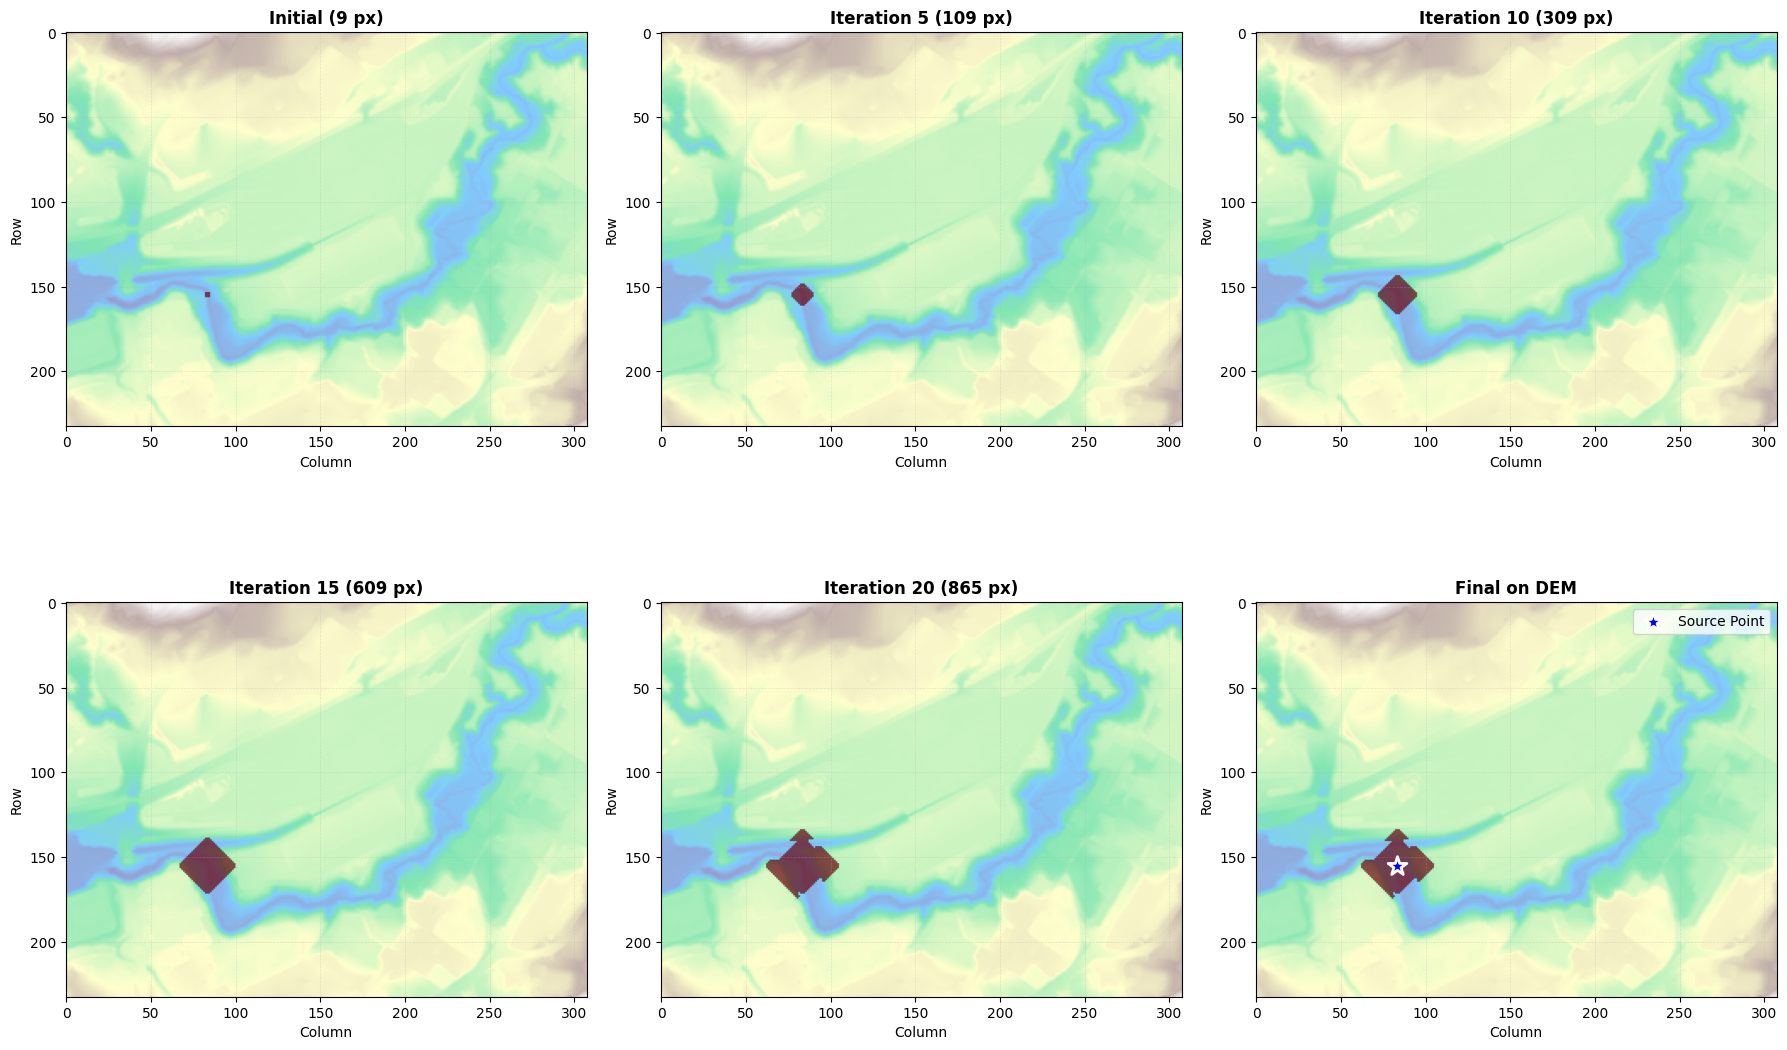


Key Observations:
1. Initial phase (iterations 1-15): Expands freely within min_length
2. After iteration 15: Slope criterion kicks in, growth slows
3. The area expands upslope from the source point
4. Growth stops when slopes become too gentle (< 1:15)


In [23]:
# Visualize the retrogression progression
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

titles = ['Initial (9 px)', 'Iteration 5 (109 px)', 'Iteration 10 (309 px)', 
          'Iteration 15 (609 px)', 'Iteration 20 (865 px)', 'Final on DEM']

for idx, (ax, title) in enumerate(zip(axes[:5], titles[:5])):
    # Show DEM as background
    ax.imshow(dem_data["full_array"], cmap='terrain', alpha=0.5)
    
    # Overlay the release area at this snapshot
    if idx < len(snapshots):
        release_overlay = np.ma.masked_where(~snapshots[idx], snapshots[idx])
        ax.imshow(release_overlay, cmap='Reds', alpha=0.7, vmin=0, vmax=1)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Column', fontsize=10)
    ax.set_ylabel('Row', fontsize=10)

# Last panel: show final result with slope classification overlay
ax = axes[5]
ax.imshow(dem_data["full_array"], cmap='terrain', alpha=0.5)

# Show the final release area
release_overlay = np.ma.masked_where(~release, release)
ax.imshow(release_overlay, cmap='Reds', alpha=0.7, vmin=0, vmax=1)

# Mark the initial source point
ax.scatter([first_source_col], [first_source_row], c='blue', s=200, marker='*', 
           edgecolors='white', linewidths=2, label='Source Point', zorder=10)

ax.set_title(titles[5], fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xlabel('Column', fontsize=10)
ax.set_ylabel('Row', fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("=" * 60)
print("1. Initial phase (iterations 1-15): Expands freely within min_length")
print("2. After iteration 15: Slope criterion kicks in, growth slows")
print("3. The area expands upslope from the source point")
print("4. Growth stops when slopes become too gentle (< 1:15)")
print("=" * 60)

### Summary: Understanding the Repository's Two Main Modules

We've now explored both major components of the `losneomrade` repository:

#### **Module 1: Terrain Criteria** (`terrain_criteria.py`)
**Purpose**: Identify all areas that meet a slope criterion from source points

**Key Functions**:
- `get_hoydedata()` - Downloads DEM from Norwegian data service
- `dem_coordinates()` - Converts raster pixels to 3D coordinates
- `set_z_from_raster()` - Samples elevations for source points
- `compute_slope()` - Calculates maximum slope from each pixel to source points
- `reclass()` - Categorizes continuous slopes into 6 hazard classes

**Output**: A raster/polygon showing all pixels with slopes ≥ threshold (typically 1:15)

#### **Module 2: Retrogression** (`retrogression.py`)
**Purpose**: Propagate a release area backward based on slope and distance criteria

**Key Functions**:
- `create_buffer()` - Expands release area by 1 pixel using binary dilation
- `landslide_retrogression()` - Iteratively grows release area
  - Phase 1 (< min_length): Expand freely without slope check
  - Phase 2 (≥ min_length): Only add pixels where slope ≥ min_slope
- `polygonize_results()` - Converts final raster to vector polygon

**Output**: A polygon representing the propagated avalanche/landslide zone

#### **Key Differences**:
1. **Terrain Criteria**: Evaluates the *entire* DEM at once (forward from sources)
2. **Retrogression**: Grows iteratively from a release area (backward propagation)

Both use the same underlying slope calculation (`compute_slope()`) but apply it differently.

### Additional Retrogression Functions We Haven't Covered

Looking at the complete `retrogression.py` file, there are several visualization and animation functions:

1. **`hillshade_img()`** - Creates hillshade visualization for 3D terrain effect
2. **`plot_hillshade_overlay()`** - Overlays release area on hillshade
3. **`animate_landslide_retrogresion()`** - Creates Plotly interactive animation
4. **`gen_animation()`** - Generates GIF animations
5. **`save_frames()`** - Saves animation frames as PNG files

Let's explore the hillshade function since it's used for better visualization:

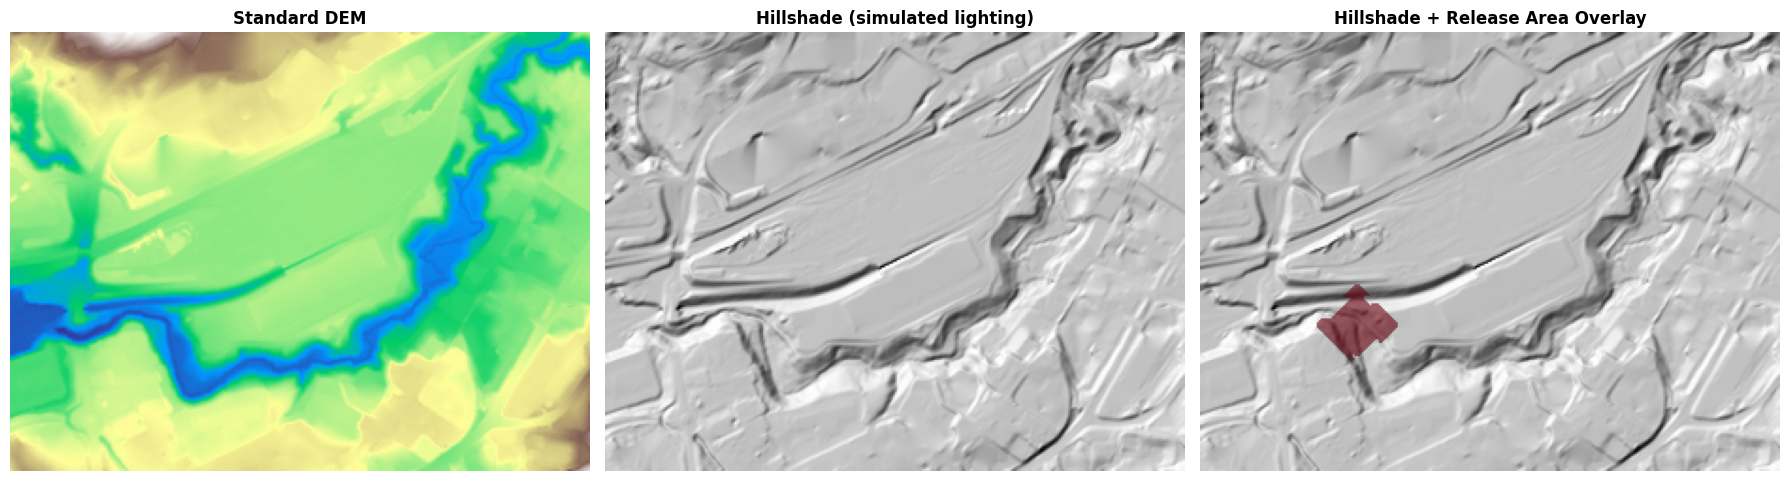

Hillshade Explanation:
- Simulates sunlight hitting terrain from northwest (315°)
- Creates shadows and highlights to show 3D terrain shape
- Vertical exaggeration (ve) amplifies elevation differences
- Makes it easier to see terrain features and slope changes


In [24]:
# Hillshade visualization from the repository
from matplotlib.colors import LightSource

def hillshade_visualization(dem_array: np.ndarray, overlay: np.ndarray = None, 
                            ve: int = 1, alpha: float = 0.5):
    """
    Create hillshade visualization (simulates lighting on terrain for 3D effect)
    Based on the repository's hillshade functions
    """
    # Create light source (sun position: azimuth=315°, altitude=45°)
    ls = LightSource(azdeg=315, altdeg=45)
    
    # Generate hillshade
    hillshade = ls.hillshade(dem_array, vert_exag=ve, dx=5, dy=5)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Plain DEM
    axes[0].imshow(dem_array, cmap='terrain')
    axes[0].set_title('Standard DEM', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Panel 2: Hillshade only
    axes[1].imshow(hillshade, cmap='gray')
    axes[1].set_title('Hillshade (simulated lighting)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Panel 3: Hillshade with overlay
    axes[2].imshow(hillshade, cmap='gray')
    if overlay is not None:
        overlay_masked = np.ma.masked_where(~overlay, overlay)
        axes[2].imshow(overlay_masked, cmap='Reds', alpha=alpha, vmin=0, vmax=1)
    axes[2].set_title('Hillshade + Release Area Overlay', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Demonstrate hillshade with our retrogression result
hillshade_visualization(dem_data["full_array"], release, ve=2, alpha=0.6)

print("Hillshade Explanation:")
print("=" * 70)
print("- Simulates sunlight hitting terrain from northwest (315°)")
print("- Creates shadows and highlights to show 3D terrain shape")
print("- Vertical exaggeration (ve) amplifies elevation differences")
print("- Makes it easier to see terrain features and slope changes")
print("=" * 70)

## Conceptual Diagrams: Terrain Criteria vs Retrogression

Now let's create clear visual diagrams to illustrate the fundamental difference between the two methods:

C:\Users\yaredbe\AppData\Local\Temp\ipykernel_15284\3219787287.py:154: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle0 = Circle((2, 4), 0.3, color='darkred', zorder=5, linewidth=2, edgecolor='white')


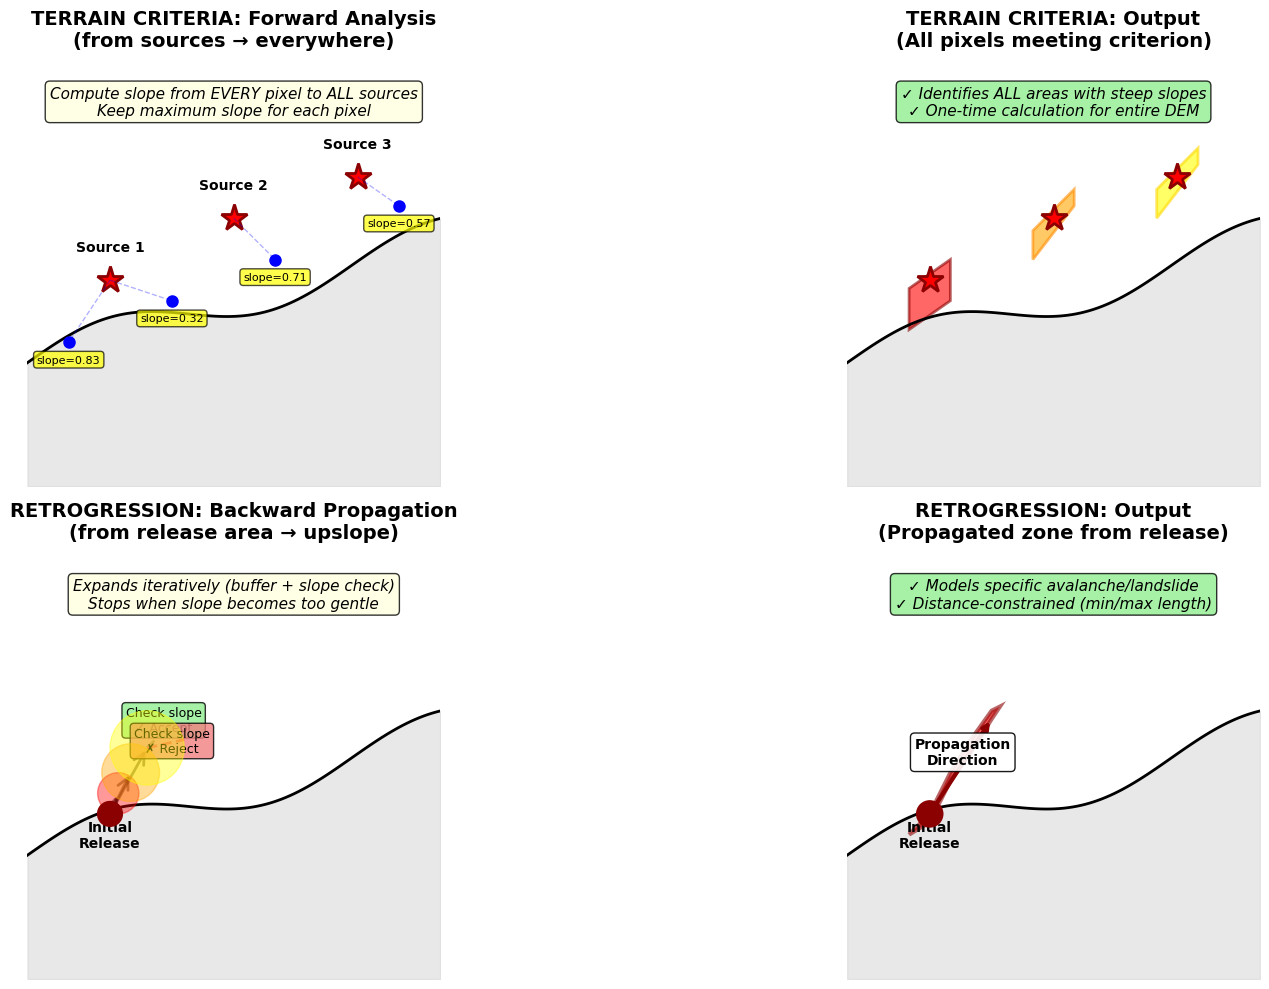

In [25]:
# Create conceptual diagrams comparing the two methods
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Circle, Polygon as mplPolygon

fig = plt.figure(figsize=(20, 10))

# ============================================================================
# DIAGRAM 1: TERRAIN CRITERIA (Forward Analysis)
# ============================================================================
ax1 = plt.subplot(2, 2, 1)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('TERRAIN CRITERIA: Forward Analysis\n(from sources → everywhere)', 
              fontsize=14, fontweight='bold', pad=20)

# Draw terrain profile
terrain_x = np.linspace(0, 10, 100)
terrain_y = 3 + 0.5 * np.sin(terrain_x * 0.8) + 0.3 * terrain_x
ax1.fill_between(terrain_x, 0, terrain_y, color='lightgray', alpha=0.5, label='Terrain')
ax1.plot(terrain_x, terrain_y, 'k-', linewidth=2)

# Source points
source_pts = [(2, 5), (5, 6.5), (8, 7.5)]
for i, (x, y) in enumerate(source_pts):
    ax1.plot(x, y, 'r*', markersize=20, markeredgecolor='darkred', markeredgewidth=2)
    ax1.text(x, y+0.7, f'Source {i+1}', ha='center', fontsize=10, fontweight='bold')

# Show rays emanating from sources to grid points
test_points = [(1, 3.5), (3.5, 4.5), (6, 5.5), (9, 6.8)]
for px, py in test_points:
    ax1.plot(px, py, 'bo', markersize=8)
    # Draw lines from nearest source
    nearest_src = min(source_pts, key=lambda s: np.sqrt((s[0]-px)**2 + (s[1]-py)**2))
    ax1.plot([nearest_src[0], px], [nearest_src[1], py], 'b--', alpha=0.3, linewidth=1)
    
    # Calculate and show slope
    dist = np.sqrt((nearest_src[0]-px)**2 + (nearest_src[1]-py)**2)
    height = nearest_src[1] - py
    slope = height / dist if dist > 0 else 0
    ax1.text(px, py-0.5, f'slope={slope:.2f}', fontsize=8, ha='center', 
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax1.text(5, 9, 'Compute slope from EVERY pixel to ALL sources\nKeep maximum slope for each pixel',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ============================================================================
# DIAGRAM 2: TERRAIN CRITERIA OUTPUT
# ============================================================================
ax2 = plt.subplot(2, 2, 2)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('TERRAIN CRITERIA: Output\n(All pixels meeting criterion)', 
              fontsize=14, fontweight='bold', pad=20)

# Draw terrain
ax2.fill_between(terrain_x, 0, terrain_y, color='lightgray', alpha=0.5)
ax2.plot(terrain_x, terrain_y, 'k-', linewidth=2)

# Draw sources
for x, y in source_pts:
    ax2.plot(x, y, 'r*', markersize=20, markeredgecolor='darkred', markeredgewidth=2)

# Show hazard zones (areas meeting slope criterion)
hazard_zone1 = mplPolygon([(1.5, 3.8), (2.5, 4.5), (2.5, 5.5), (1.5, 4.8)], 
                          facecolor='red', alpha=0.6, edgecolor='darkred', linewidth=2)
hazard_zone2 = mplPolygon([(4.5, 5.5), (5.5, 6.8), (5.5, 7.2), (4.5, 6.2)], 
                          facecolor='orange', alpha=0.6, edgecolor='darkorange', linewidth=2)
hazard_zone3 = mplPolygon([(7.5, 6.5), (8.5, 7.8), (8.5, 8.2), (7.5, 7.2)], 
                          facecolor='yellow', alpha=0.6, edgecolor='gold', linewidth=2)
ax2.add_patch(hazard_zone1)
ax2.add_patch(hazard_zone2)
ax2.add_patch(hazard_zone3)

ax2.text(5, 9, '✓ Identifies ALL areas with steep slopes\n✓ One-time calculation for entire DEM',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# ============================================================================
# DIAGRAM 3: RETROGRESSION (Backward Propagation)
# ============================================================================
ax3 = plt.subplot(2, 2, 3)
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.set_aspect('equal')
ax3.axis('off')
ax3.set_title('RETROGRESSION: Backward Propagation\n(from release area → upslope)', 
              fontsize=14, fontweight='bold', pad=20)

# Draw terrain
ax3.fill_between(terrain_x, 0, terrain_y, color='lightgray', alpha=0.5)
ax3.plot(terrain_x, terrain_y, 'k-', linewidth=2)

# Initial release area
release_x, release_y = 2, 4
circle0 = Circle((release_x, release_y), 0.3, color='darkred', zorder=5)
ax3.add_patch(circle0)
ax3.text(release_x, release_y-0.8, 'Initial\nRelease', ha='center', fontsize=10, fontweight='bold')

# Show iterative expansion
circles_data = [
    (2.2, 4.5, 0.5, 'Iter 1', 'red'),
    (2.5, 5.0, 0.7, 'Iter 2', 'orange'),
    (2.9, 5.6, 0.9, 'Iter 3', 'yellow'),
]

for x, y, r, label, color in circles_data:
    circle = Circle((x, y), r, color=color, alpha=0.4, zorder=4)
    ax3.add_patch(circle)
    arrow = FancyArrowPatch((release_x, release_y), (x, y),
                           arrowstyle='->', mutation_scale=20, linewidth=2,
                           color='black', alpha=0.5)
    ax3.add_patch(arrow)

# Show slope checking
ax3.plot([2.9, 3.5], [5.6, 6.2], 'g--', linewidth=2)
ax3.text(3.3, 6.0, 'Check slope\n✓ Accept', fontsize=9, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

ax3.plot([2.9, 3.8], [5.6, 5.8], 'r--', linewidth=2)
ax3.text(3.5, 5.5, 'Check slope\n✗ Reject', fontsize=9, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

ax3.text(5, 9, 'Expands iteratively (buffer + slope check)\nStops when slope becomes too gentle',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ============================================================================
# DIAGRAM 4: RETROGRESSION OUTPUT
# ============================================================================
ax4 = plt.subplot(2, 2, 4)
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 10)
ax4.set_aspect('equal')
ax4.axis('off')
ax4.set_title('RETROGRESSION: Output\n(Propagated zone from release)', 
              fontsize=14, fontweight='bold', pad=20)

# Draw terrain
ax4.fill_between(terrain_x, 0, terrain_y, color='lightgray', alpha=0.5)
ax4.plot(terrain_x, terrain_y, 'k-', linewidth=2)

# Show final propagated zone
final_zone = mplPolygon([(1.5, 3.5), (2, 4), (2.5, 5), (3, 5.8), (3.5, 6.5), 
                         (3.7, 6.6), (3.5, 6.3), (3, 5.5), (2.5, 4.8), (2, 3.8)], 
                        facecolor='red', alpha=0.6, edgecolor='darkred', linewidth=3)
ax4.add_patch(final_zone)

# Mark initial release
circle0 = Circle((2, 4), 0.3, color='darkred', zorder=5, linewidth=2, edgecolor='white')
ax4.add_patch(circle0)
ax4.text(2, 3.2, 'Initial\nRelease', ha='center', fontsize=10, fontweight='bold')

# Arrows showing growth direction
ax4.annotate('', xy=(3.5, 6.3), xytext=(2, 4),
            arrowprops=dict(arrowstyle='->', lw=3, color='darkred'))
ax4.text(2.8, 5.2, 'Propagation\nDirection', ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax4.text(5, 9, '✓ Models specific avalanche/landslide\n✓ Distance-constrained (min/max length)',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

### Complete Summary: All Retrogression Functions

Here's the complete list of functions in `retrogression.py` and their purposes:

#### **Core Algorithm Functions:**
1. **`run_retrogression()`** - Main wrapper function
   - Gets/loads DEM data
   - Rasterizes input release shape (polygon/line/points)
   - Calls `landslide_retrogression()`
   - Polygonizes and returns results
   - Optionally returns animation frames

2. **`landslide_retrogression()`** - The core iterative algorithm
   - Inputs: DEM, initial release area (raster), transform, slope/height/length criteria
   - Algorithm:
     - Loop until max_length or no expansion
     - Each iteration: buffer release by 1 pixel
     - Get coordinates of buffered pixels
     - Compute slopes from buffered pixels to release area
     - If beyond min_length: filter by slope criterion
     - Add qualifying pixels to release
   - Returns: final release area + animation frames

3. **`create_buffer()`** - Expands release area by 1 pixel
   - Uses binary dilation
   - Returns only the new boundary pixels (not cumulative)

#### **Visualization Functions:**
4. **`hillshade_img()`** - Creates hillshade for Plotly
   - Simulates lighting (azimuth=315°, altitude=45°)
   - Returns Plotly Image object
   - Used in animations

5. **`plot_hillshade_overlay()`** - Static matplotlib visualization
   - Combines hillshade with release area overlay
   - Customizable transparency and vertical exaggeration
   - Returns matplotlib figure

6. **`animate_landslide_retrogresion()`** - Interactive Plotly animation
   - Creates frame-by-frame animation showing propagation
   - Hillshade background with red overlay for release area
   - Returns Plotly Figure with play button

#### **Animation Export Functions:**
7. **`gen_animation()`** - Generate GIF from frames
   - Creates list of PIL images from matplotlib figures
   - Can save directly as GIF file
   - Configurable frame skip

8. **`save_frames()`** - Export animation frames as PNGs
   - Saves each frame as separate PNG file
   - Useful for creating GIFs with external tools
   - Progress bar with tqdm

### When to Use Each Method:

**Use Terrain Criteria when:**
- You have source points/lines but no defined release area
- You want to identify ALL potentially hazardous slopes
- You need a complete hazard map for an entire region
- Planning/mapping phase of analysis

**Use Retrogression when:**
- You have a known/suspected release area
- You want to model a specific landslide/avalanche event
- You need distance-constrained propagation (min/max length)
- Detailed analysis of individual events

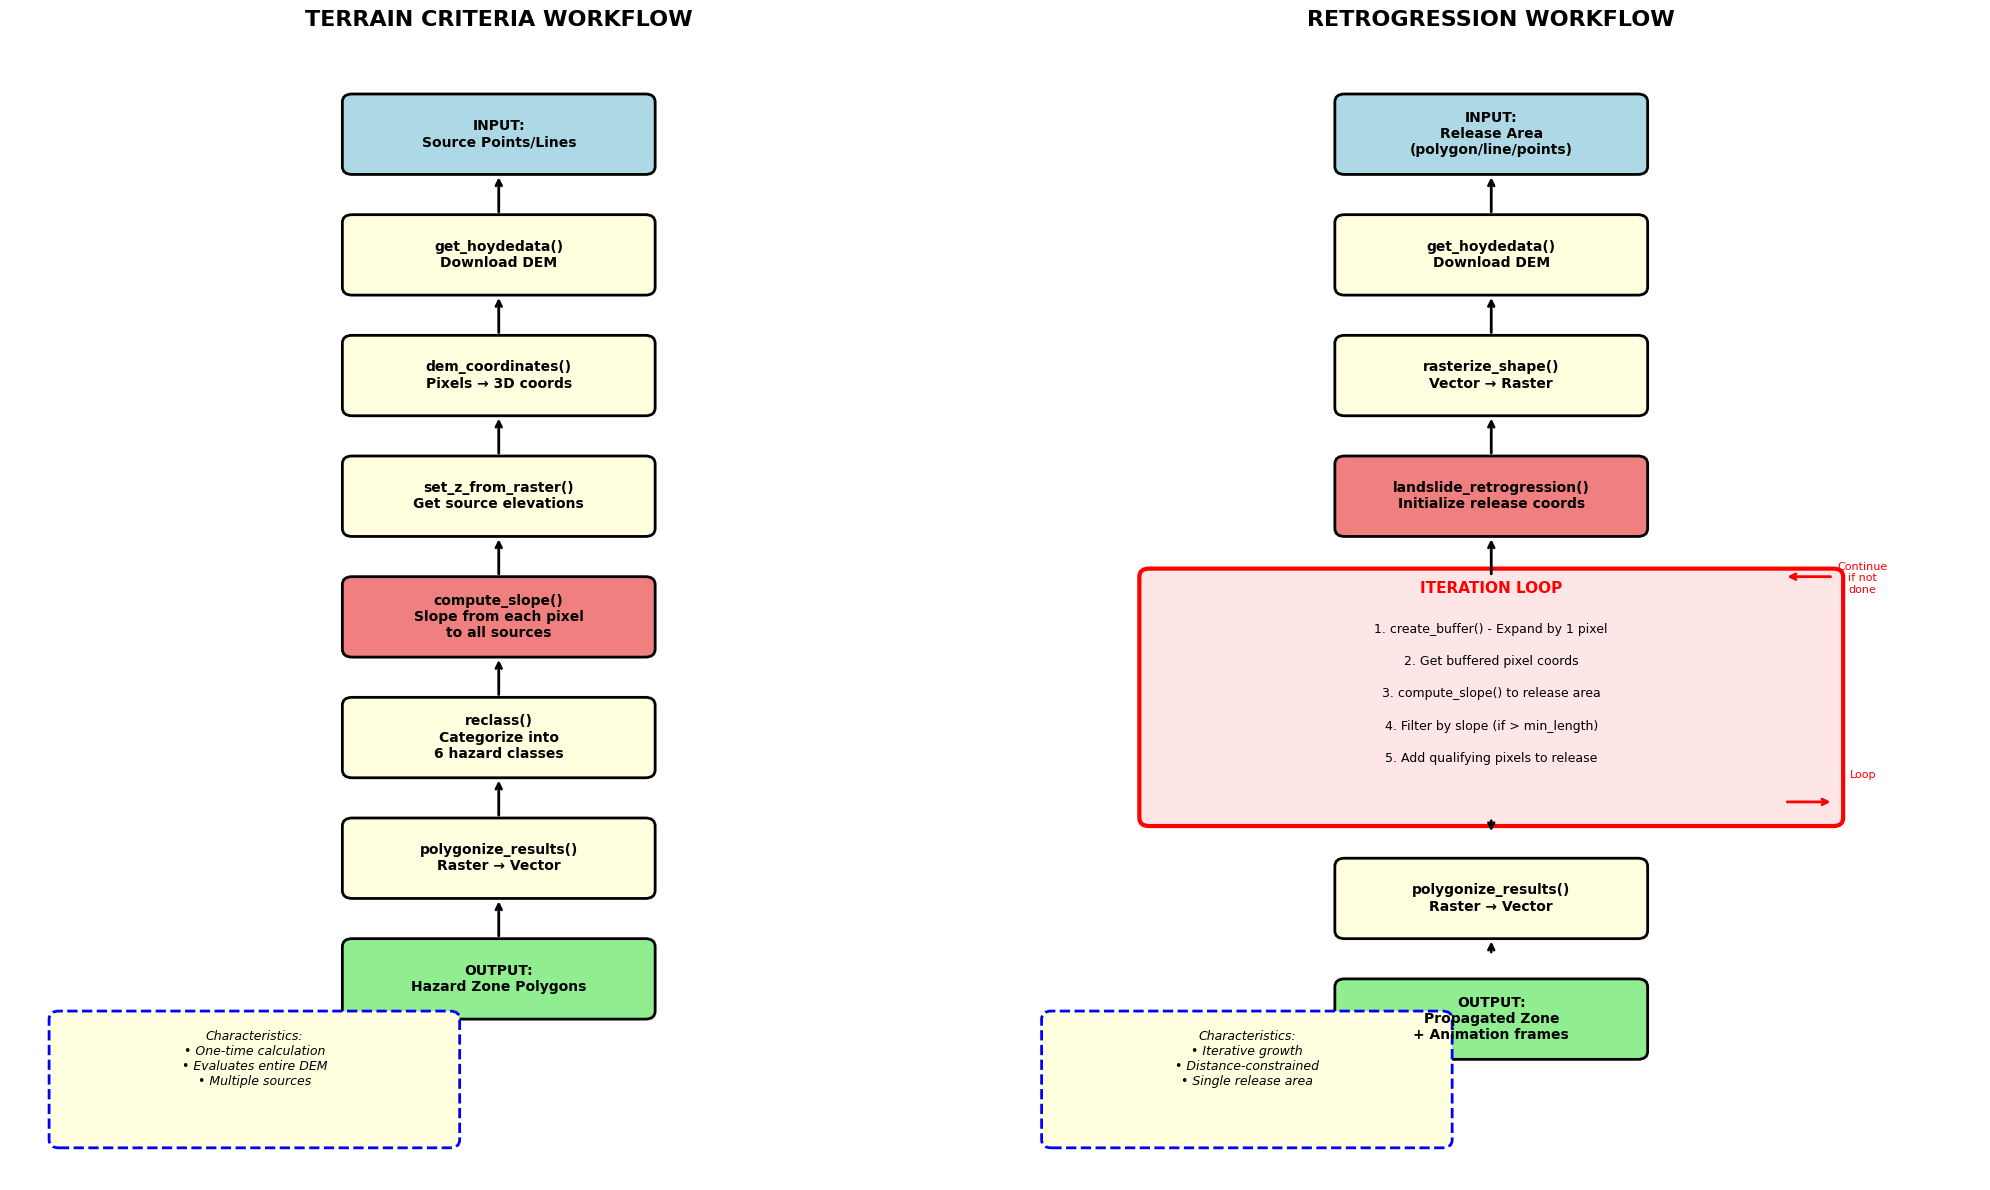


KEY INSIGHT: Both methods use compute_slope() but apply it differently!
TERRAIN CRITERIA: Vectorized - computes ALL pixels at once
RETROGRESSION:    Iterative - computes new boundary pixels each step


In [26]:
# Create a comprehensive workflow diagram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))

# ============================================================================
# LEFT: Terrain Criteria Workflow
# ============================================================================
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 14)
ax1.axis('off')
ax1.set_title('TERRAIN CRITERIA WORKFLOW', fontsize=16, fontweight='bold', pad=20)

# Workflow boxes
boxes_tc = [
    (5, 13, "INPUT:\nSource Points/Lines", 'lightblue'),
    (5, 11.5, "get_hoydedata()\nDownload DEM", 'lightyellow'),
    (5, 10, "dem_coordinates()\nPixels → 3D coords", 'lightyellow'),
    (5, 8.5, "set_z_from_raster()\nGet source elevations", 'lightyellow'),
    (5, 7, "compute_slope()\nSlope from each pixel\nto all sources", 'lightcoral'),
    (5, 5.5, "reclass()\nCategorize into\n6 hazard classes", 'lightyellow'),
    (5, 4, "polygonize_results()\nRaster → Vector", 'lightyellow'),
    (5, 2.5, "OUTPUT:\nHazard Zone Polygons", 'lightgreen'),
]

for x, y, text, color in boxes_tc:
    bbox = mpatches.FancyBboxPatch((x-1.5, y-0.4), 3, 0.8, 
                                   boxstyle="round,pad=0.1", 
                                   facecolor=color, edgecolor='black', linewidth=2)
    ax1.add_patch(bbox)
    ax1.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Add arrows between boxes
    if y > 2.5:
        ax1.annotate('', xy=(x, y-0.5), xytext=(x, y-1.0),
                    arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Add characteristics box
char_box = mpatches.FancyBboxPatch((0.5, 0.5), 4, 1.5,
                                   boxstyle="round,pad=0.1",
                                   facecolor='lightyellow', edgecolor='blue', 
                                   linewidth=2, linestyle='--')
ax1.add_patch(char_box)
ax1.text(2.5, 1.5, 'Characteristics:\n• One-time calculation\n• Evaluates entire DEM\n• Multiple sources', 
         ha='center', va='center', fontsize=9, style='italic')

# ============================================================================
# RIGHT: Retrogression Workflow
# ============================================================================
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 14)
ax2.axis('off')
ax2.set_title('RETROGRESSION WORKFLOW', fontsize=16, fontweight='bold', pad=20)

# Workflow boxes
boxes_retro = [
    (5, 13, "INPUT:\nRelease Area\n(polygon/line/points)", 'lightblue'),
    (5, 11.5, "get_hoydedata()\nDownload DEM", 'lightyellow'),
    (5, 10, "rasterize_shape()\nVector → Raster", 'lightyellow'),
    (5, 8.5, "landslide_retrogression()\nInitialize release coords", 'lightcoral'),
]

for x, y, text, color in boxes_retro[:4]:
    bbox = mpatches.FancyBboxPatch((x-1.5, y-0.4), 3, 0.8, 
                                   boxstyle="round,pad=0.1", 
                                   facecolor=color, edgecolor='black', linewidth=2)
    ax2.add_patch(bbox)
    ax2.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')
    ax2.annotate('', xy=(x, y-0.5), xytext=(x, y-1.0),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Iteration loop box
loop_box = mpatches.FancyBboxPatch((1.5, 4.5), 7, 3,
                                   boxstyle="round,pad=0.1",
                                   facecolor='#ffe6e6', edgecolor='red', linewidth=3)
ax2.add_patch(loop_box)
ax2.text(5, 7.3, 'ITERATION LOOP', ha='center', fontsize=11, fontweight='bold', color='red')

loop_steps = [
    "1. create_buffer() - Expand by 1 pixel",
    "2. Get buffered pixel coords",
    "3. compute_slope() to release area",
    "4. Filter by slope (if > min_length)",
    "5. Add qualifying pixels to release",
]
for i, step in enumerate(loop_steps):
    ax2.text(5, 6.8 - i*0.4, step, ha='center', fontsize=9)

# Loop arrows
ax2.annotate('', xy=(8, 7.5), xytext=(8.5, 7.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax2.annotate('', xy=(8.5, 4.7), xytext=(8, 4.7),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax2.text(8.8, 7.3, 'Continue\nif not\ndone', ha='center', fontsize=8, color='red')
ax2.text(8.8, 5, 'Loop', ha='center', fontsize=8, color='red')

# Exit from loop
ax2.annotate('', xy=(5, 4.3), xytext=(5, 4.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Final steps
final_boxes = [
    (5, 3.5, "polygonize_results()\nRaster → Vector", 'lightyellow'),
    (5, 2, "OUTPUT:\nPropagated Zone\n+ Animation frames", 'lightgreen'),
]

for x, y, text, color in final_boxes:
    bbox = mpatches.FancyBboxPatch((x-1.5, y-0.4), 3, 0.8, 
                                   boxstyle="round,pad=0.1", 
                                   facecolor=color, edgecolor='black', linewidth=2)
    ax2.add_patch(bbox)
    ax2.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')
    if y > 2:
        ax2.annotate('', xy=(x, y-0.5), xytext=(x, y-0.7),
                    arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Add characteristics box
char_box2 = mpatches.FancyBboxPatch((0.5, 0.5), 4, 1.5,
                                   boxstyle="round,pad=0.1",
                                   facecolor='lightyellow', edgecolor='blue', 
                                   linewidth=2, linestyle='--')
ax2.add_patch(char_box2)
ax2.text(2.5, 1.5, 'Characteristics:\n• Iterative growth\n• Distance-constrained\n• Single release area', 
         ha='center', va='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY INSIGHT: Both methods use compute_slope() but apply it differently!")
print("="*80)
print("TERRAIN CRITERIA: Vectorized - computes ALL pixels at once")
print("RETROGRESSION:    Iterative - computes new boundary pixels each step")
print("="*80)

## Detailed Function Call Mapping (Including utils.py)

Now let's create detailed diagrams showing EVERY function call, including those from `utils.py`:


C:\Users\yaredbe\AppData\Local\Temp\ipykernel_15284\2771771643.py:269: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


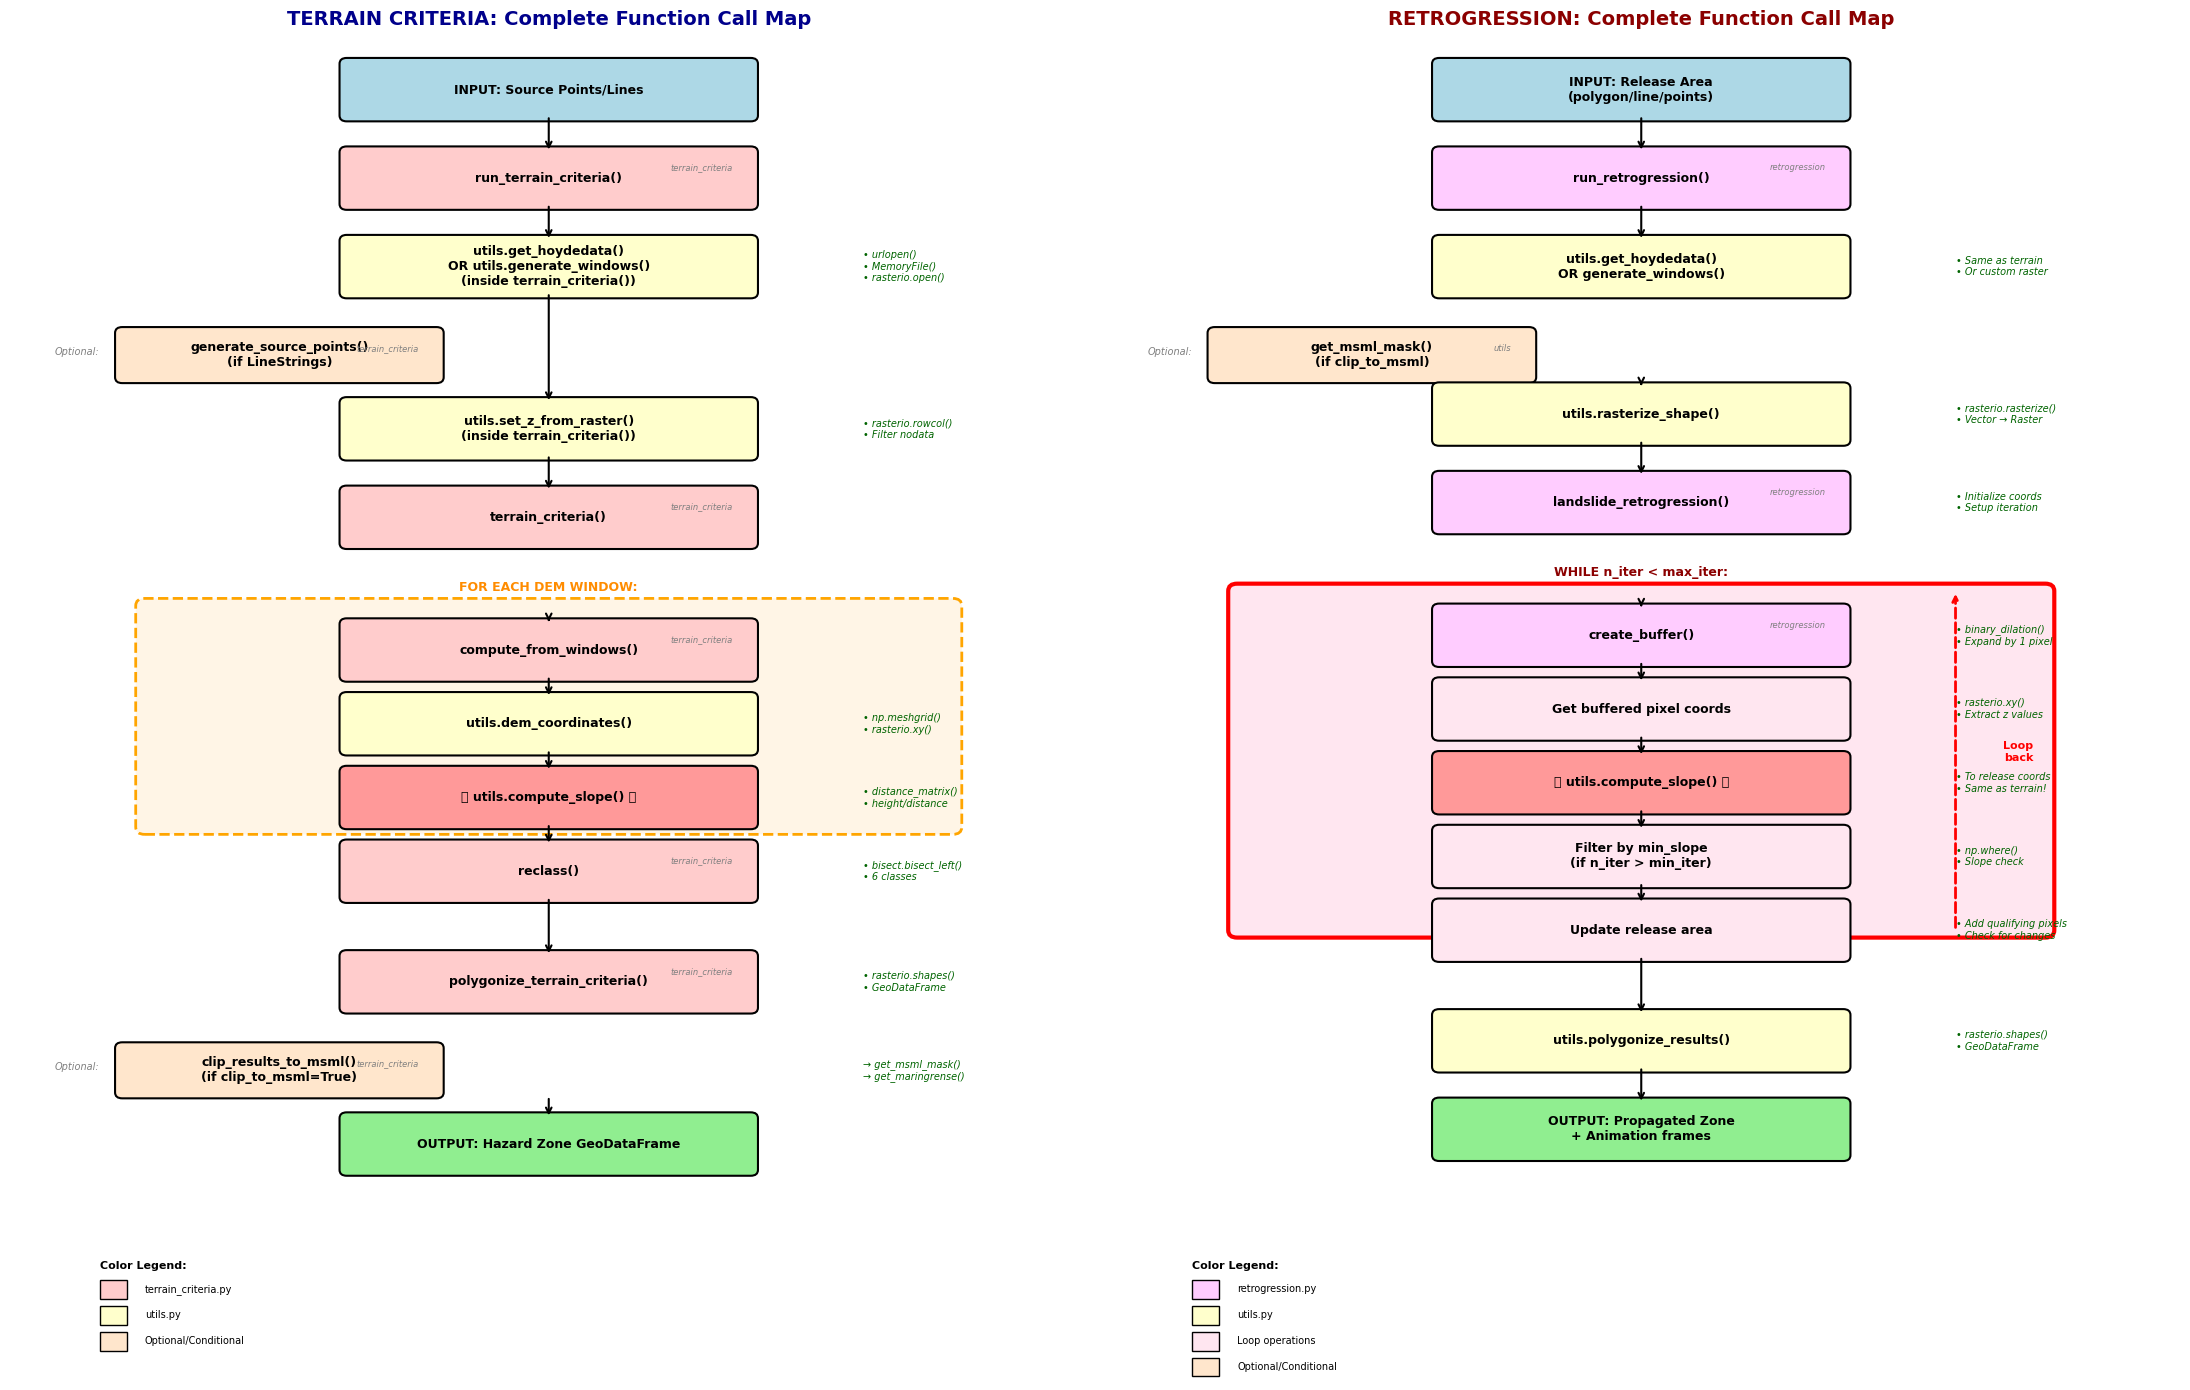


COMPLETE FUNCTION MAPPING

Shared utils (used by BOTH methods):
  • get_hoydedata() - DEM download
  • generate_windows() - Custom raster tiling
  • compute_slope() - Core slope calculation
  • get_msml_mask() - Optional MSML clip support

Terrain Criteria Specific:
  • terrain_criteria.run_terrain_criteria() - Main entry point
  • terrain_criteria.terrain_criteria() - Core algorithm
  • terrain_criteria.compute_from_windows() - Window processing
  • terrain_criteria.reclass() - Classification into 6 classes
  • terrain_criteria.polygonize_terrain_criteria() - Raster → vector (TC-specific)
  • terrain_criteria.clip_results_to_msml() - Optional clipping
  • terrain_criteria.generate_source_points() - LineString → Points
    (uses utils.set_z_from_raster() and utils.dem_coordinates() internally)

Retrogression Specific:
  • retrogression.run_retrogression() - Main entry point
  • retrogression.landslide_retrogression() - Core iterative algorithm
  • retrogression.create_buffer() - Expan

In [28]:
# Create detailed workflow diagrams showing ALL function calls including from utils.py
fig = plt.figure(figsize=(22, 14))

# ============================================================================
# LEFT: TERRAIN CRITERIA - Complete Function Mapping
# ============================================================================
ax1 = plt.subplot(1, 2, 1)
ax1.set_xlim(0, 12)
ax1.set_ylim(0, 18)
ax1.axis('off')
ax1.set_title('TERRAIN CRITERIA: Complete Function Call Map', 
              fontsize=14, fontweight='bold', pad=20, color='darkblue')

y_pos = 17.5
box_width = 4.5
indent = 0

def add_box(ax, x, y, text, color, width=4.5, height=0.7, module='', arrow_from=None):
    """Helper to add a box with optional module label"""
    bbox = mpatches.FancyBboxPatch((x-width/2, y-height/2), width, height, 
                                   boxstyle="round,pad=0.08", 
                                   facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(bbox)
    
    # Main text
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Module label
    if module:
        ax.text(x + width/2 - 0.2, y + height/2 - 0.15, module, 
               ha='right', va='top', fontsize=6, style='italic', color='gray')
    
    # Arrow from previous
    if arrow_from is not None:
        ax.annotate('', xy=(x, y + height/2), xytext=(arrow_from[0], arrow_from[1] - 0.35),
                   arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
    
    return (x, y)

# Input
last_pos = add_box(ax1, 6, y_pos, 'INPUT: Source Points/Lines', 'lightblue', width=box_width)
y_pos -= 1.2

# terrain_criteria.run_terrain_criteria()
last_pos = add_box(ax1, 6, y_pos, 'run_terrain_criteria()', '#ffcccc', 
                   width=box_width, module='terrain_criteria', arrow_from=last_pos)
y_pos -= 1.2

# utils.get_hoydedata() OR utils.generate_windows() (inside terrain_criteria())
last_pos = add_box(ax1, 6, y_pos, 'utils.get_hoydedata()\nOR utils.generate_windows()\n(inside terrain_criteria())', '#ffffcc', 
                   width=box_width, arrow_from=last_pos)
ax1.text(9.5, y_pos, '• urlopen()\n• MemoryFile()\n• rasterio.open()', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.2

# Optional: generate_source_points
add_box(ax1, 3, y_pos, 'generate_source_points()\n(if LineStrings)', '#ffe6cc', 
        width=3.5, height=0.6, module='terrain_criteria')
ax1.text(0.5, y_pos, 'Optional:', fontsize=7, style='italic', color='gray')
y_pos -= 1.0

# utils.set_z_from_raster() (inside terrain_criteria())
last_pos = add_box(ax1, 6, y_pos, 'utils.set_z_from_raster()\n(inside terrain_criteria())', '#ffffcc', 
                   width=box_width, arrow_from=last_pos)
ax1.text(9.5, y_pos, '• rasterio.rowcol()\n• Filter nodata', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.2

# terrain_criteria.terrain_criteria()
last_pos = add_box(ax1, 6, y_pos, 'terrain_criteria()', '#ffcccc', 
                   width=box_width, module='terrain_criteria', arrow_from=last_pos)
y_pos -= 1.0

# Loop over windows
loop_box = mpatches.FancyBboxPatch((1.5, y_pos-3.2), 9, 3, 
                                   boxstyle="round,pad=0.1",
                                   facecolor='#fff5e6', edgecolor='orange', 
                                   linewidth=2, linestyle='--')
ax1.add_patch(loop_box)
ax1.text(6, y_pos, 'FOR EACH DEM WINDOW:', ha='center', fontsize=9, 
         fontweight='bold', color='darkorange')
y_pos -= 0.8

# compute_from_windows()
last_pos = add_box(ax1, 6, y_pos, 'compute_from_windows()', '#ffcccc', 
                   width=box_width, module='terrain_criteria', arrow_from=(6, y_pos+0.8))
y_pos -= 1.0

# utils.dem_coordinates()
last_pos = add_box(ax1, 6, y_pos, 'utils.dem_coordinates()', '#ffffcc', 
                   width=box_width, arrow_from=last_pos)
ax1.text(9.5, y_pos, '• np.meshgrid()\n• rasterio.xy()', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.0

# utils.compute_slope() - THE CORE
last_pos = add_box(ax1, 6, y_pos, '⭐ utils.compute_slope() ⭐', '#ff9999', 
                   width=box_width, arrow_from=last_pos)
ax1.text(9.5, y_pos, '• distance_matrix()\n• height/distance', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.0

# reclass()
last_pos = add_box(ax1, 6, y_pos, 'reclass()', '#ffcccc', 
                   width=box_width, module='terrain_criteria', arrow_from=last_pos)
ax1.text(9.5, y_pos, '• bisect.bisect_left()\n• 6 classes', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.5

# polygonize_terrain_criteria() (module-local)
last_pos = add_box(ax1, 6, y_pos, 'polygonize_terrain_criteria()', '#ffcccc', 
                   width=box_width, module='terrain_criteria', arrow_from=(6, y_pos+1.5))
ax1.text(9.5, y_pos, '• rasterio.shapes()\n• GeoDataFrame', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.2

# Optional: clip_to_msml
add_box(ax1, 3, y_pos, 'clip_results_to_msml()\n(if clip_to_msml=True)', '#ffe6cc', 
        width=3.5, height=0.6, module='terrain_criteria')
ax1.text(9.5, y_pos, '→ get_msml_mask()\n→ get_maringrense()', 
         fontsize=7, va='center', color='darkgreen', style='italic')
ax1.text(0.5, y_pos, 'Optional:', fontsize=7, style='italic', color='gray')
y_pos -= 1.0

# Output
add_box(ax1, 6, y_pos, 'OUTPUT: Hazard Zone GeoDataFrame', 'lightgreen', 
        width=box_width, arrow_from=(6, y_pos+1.0))

# Legend
legend_y = 1.5
ax1.text(1, legend_y, 'Color Legend:', fontsize=8, fontweight='bold')
legend_items = [
    ('#ffcccc', 'terrain_criteria.py'),
    ('#ffffcc', 'utils.py'),
    ('#ffe6cc', 'Optional/Conditional'),
]
for i, (color, label) in enumerate(legend_items):
    box = mpatches.Rectangle((1, legend_y - 0.4 - i*0.35), 0.3, 0.25, 
                             facecolor=color, edgecolor='black')
    ax1.add_patch(box)
    ax1.text(1.5, legend_y - 0.27 - i*0.35, label, fontsize=7, va='center')

# ============================================================================
# RIGHT: RETROGRESSION - Complete Function Mapping
# ============================================================================
ax2 = plt.subplot(1, 2, 2)
ax2.set_xlim(0, 12)
ax2.set_ylim(0, 18)
ax2.axis('off')
ax2.set_title('RETROGRESSION: Complete Function Call Map', 
              fontsize=14, fontweight='bold', pad=20, color='darkred')

y_pos = 17.5

# Input
last_pos = add_box(ax2, 6, y_pos, 'INPUT: Release Area\n(polygon/line/points)', 'lightblue', width=box_width)
y_pos -= 1.2

# retrogression.run_retrogression()
last_pos = add_box(ax2, 6, y_pos, 'run_retrogression()', '#ffccff', 
                   width=box_width, module='retrogression', arrow_from=last_pos)
y_pos -= 1.2

# utils.get_hoydedata() OR utils.generate_windows()
last_pos = add_box(ax2, 6, y_pos, 'utils.get_hoydedata()\nOR generate_windows()', '#ffffcc', 
                   width=box_width, arrow_from=last_pos)
ax2.text(9.5, y_pos, '• Same as terrain\n• Or custom raster', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.2

# Optional: get_msml_mask
add_box(ax2, 3, y_pos, 'get_msml_mask()\n(if clip_to_msml)', '#ffe6cc', 
        width=3.5, height=0.6, module='utils')
ax2.text(0.5, y_pos, 'Optional:', fontsize=7, style='italic', color='gray')
y_pos -= 0.8

# utils.rasterize_shape() (release + optional MSML mask)
last_pos = add_box(ax2, 6, y_pos, 'utils.rasterize_shape()', '#ffffcc', 
                   width=box_width, arrow_from=(6, y_pos+0.8))
ax2.text(9.5, y_pos, '• rasterio.rasterize()\n• Vector → Raster', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.2

# landslide_retrogression()
last_pos = add_box(ax2, 6, y_pos, 'landslide_retrogression()', '#ffccff', 
                   width=box_width, module='retrogression', arrow_from=last_pos)
ax2.text(9.5, y_pos, '• Initialize coords\n• Setup iteration', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.0

# Main iteration loop
loop_box2 = mpatches.FancyBboxPatch((1.5, y_pos-4.8), 9, 4.6, 
                                    boxstyle="round,pad=0.1",
                                    facecolor='#ffe6f0', edgecolor='red', 
                                    linewidth=3)
ax2.add_patch(loop_box2)
ax2.text(6, y_pos, 'WHILE n_iter < max_iter:', ha='center', fontsize=9, 
         fontweight='bold', color='darkred')
y_pos -= 0.8

# create_buffer()
last_pos = add_box(ax2, 6, y_pos, 'create_buffer()', '#ffccff', 
                   width=box_width, module='retrogression', arrow_from=(6, y_pos+0.8))
ax2.text(9.5, y_pos, '• binary_dilation()\n• Expand by 1 pixel', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.0

# Get buffered coordinates
last_pos = add_box(ax2, 6, y_pos, 'Get buffered pixel coords', '#ffe6f0', 
                   width=box_width, arrow_from=last_pos)
ax2.text(9.5, y_pos, '• rasterio.xy()\n• Extract z values', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.0

# utils.compute_slope() - THE CORE
last_pos = add_box(ax2, 6, y_pos, '⭐ utils.compute_slope() ⭐', '#ff9999', 
                   width=box_width, arrow_from=last_pos)
ax2.text(9.5, y_pos, '• To release coords\n• Same as terrain!', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.0

# Filter by slope
last_pos = add_box(ax2, 6, y_pos, 'Filter by min_slope\n(if n_iter > min_iter)', '#ffe6f0', 
                   width=box_width, arrow_from=last_pos)
ax2.text(9.5, y_pos, '• np.where()\n• Slope check', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.0

# Update release
last_pos = add_box(ax2, 6, y_pos, 'Update release area', '#ffe6f0', 
                   width=box_width, arrow_from=last_pos)
ax2.text(9.5, y_pos, '• Add qualifying pixels\n• Check for changes', 
         fontsize=7, va='center', color='darkgreen', style='italic')

# Loop back arrow
ax2.annotate('', xy=(9.5, y_pos + 4.6), xytext=(9.5, y_pos),
            arrowprops=dict(arrowstyle='->', lw=2, color='red', linestyle='--'))
ax2.text(10.2, y_pos + 2.3, 'Loop\nback', ha='center', fontsize=8, 
         color='red', fontweight='bold', rotation=0)

y_pos -= 1.5

# utils.polygonize_results()
last_pos = add_box(ax2, 6, y_pos, 'utils.polygonize_results()', '#ffffcc', 
                   width=box_width, arrow_from=(6, y_pos+1.5))
ax2.text(9.5, y_pos, '• rasterio.shapes()\n• GeoDataFrame', 
         fontsize=7, va='center', color='darkgreen', style='italic')
y_pos -= 1.2

# Output
add_box(ax2, 6, y_pos, 'OUTPUT: Propagated Zone\n+ Animation frames', 'lightgreen', 
        width=box_width, arrow_from=(6, y_pos+1.2))

# Legend
legend_y = 1.5
ax2.text(1, legend_y, 'Color Legend:', fontsize=8, fontweight='bold')
legend_items2 = [
    ('#ffccff', 'retrogression.py'),
    ('#ffffcc', 'utils.py'),
    ('#ffe6f0', 'Loop operations'),
    ('#ffe6cc', 'Optional/Conditional'),
]
for i, (color, label) in enumerate(legend_items2):
    box = mpatches.Rectangle((1, legend_y - 0.4 - i*0.35), 0.3, 0.25, 
                             facecolor=color, edgecolor='black')
    ax2.add_patch(box)
    ax2.text(1.5, legend_y - 0.27 - i*0.35, label, fontsize=7, va='center')

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("COMPLETE FUNCTION MAPPING")
print("="*90)
print("\nShared utils (used by BOTH methods):")
print("  • get_hoydedata() - DEM download")
print("  • generate_windows() - Custom raster tiling")
print("  • compute_slope() - Core slope calculation")
print("  • get_msml_mask() - Optional MSML clip support")
print("\nTerrain Criteria Specific:")
print("  • terrain_criteria.run_terrain_criteria() - Main entry point")
print("  • terrain_criteria.terrain_criteria() - Core algorithm")
print("  • terrain_criteria.compute_from_windows() - Window processing")
print("  • terrain_criteria.reclass() - Classification into 6 classes")
print("  • terrain_criteria.polygonize_terrain_criteria() - Raster → vector (TC-specific)")
print("  • terrain_criteria.clip_results_to_msml() - Optional clipping")
print("  • terrain_criteria.generate_source_points() - LineString → Points")
print("    (uses utils.set_z_from_raster() and utils.dem_coordinates() internally)")
print("\nRetrogression Specific:")
print("  • retrogression.run_retrogression() - Main entry point")
print("  • retrogression.landslide_retrogression() - Core iterative algorithm")
print("  • retrogression.create_buffer() - Expand release area")
print("  • utils.rasterize_shape() - Vector → Raster (release and optional MSML mask)")
print("  • utils.polygonize_results() - Raster → vector (retrogression output)")
print("  • (viz helpers) animate_landslide_retrogresion(), plot_hillshade_overlay(), gen_animation(), save_frames()")
print("="*90)

## 🎉 Complete Understanding Achieved!

You now have a comprehensive understanding of the **losneomrade** repository!

### What We've Covered:

#### **Part 1: Terrain Criteria Module** (`terrain_criteria.py`)
✅ Data acquisition: `get_hoydedata()`  
✅ Coordinate transformations: `dem_coordinates()`, affine transforms  
✅ Elevation sampling: `set_z_from_raster()`  
✅ Slope computation: `compute_slope()` - the core calculation  
✅ Classification: `reclass()` - 6 hazard classes  
✅ Visualization: slope maps and classified zones  

#### **Part 2: Retrogression Module** (`retrogression.py`)
✅ Wrapper function: `run_retrogression()`  
✅ Core algorithm: `landslide_retrogression()` with iterative buffering  
✅ Buffer expansion: `create_buffer()` using binary dilation  
✅ Hillshade visualization: `hillshade_img()`, `plot_hillshade_overlay()`  
✅ Animation functions: `animate_landslide_retrogresion()`, `gen_animation()`, `save_frames()`  
✅ Complete workflow understanding with diagrams  

#### **Part 3: Conceptual Understanding**
✅ Forward analysis vs backward propagation  
✅ When to use each method  
✅ Key differences in computation approach  
✅ Visual diagrams illustrating both concepts  
✅ Complete workflow diagrams  

### Key Takeaways:

1. **Both methods share `compute_slope()`** - it's the fundamental calculation
2. **Terrain Criteria** = One-time vectorized calculation across entire DEM
3. **Retrogression** = Iterative expansion with slope checking at each step
4. The repository is well-structured with separate modules for each approach
5. Visualization tools (hillshade, animations) make results interpretable

### You're Now Ready To:
- Make informed modifications to the codebase
- Understand performance implications of changes
- Add new features or extend functionality
- Debug issues with full context
- Explain the methods to others

**Great job working through this systematically! 🚀**